# States, observables and entanglement

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 3 — The matrix-free engine*

## 1. Introduction and motivation

A state of $N$ spins-1/2 is a list of $2^N$ complex numbers. For $N=14$ that is $16\,384$ amplitudes, for $N=30$ a billion.
Such a list cannot be read directly, and a laboratory never returns it either: it returns a magnetisation, a correlation
between two sites, a histogram of clicks. The practical task of many-body physics is therefore to find a few numbers,
computed from $|\psi\rangle$, that characterise the state. This notebook builds the toolbox for that task. There are two families of tools.

1. **Observables that live on a few spins** — local magnetisations $\langle\sigma^z_i\rangle$, two-point correlators
   $\langle\sigma^z_i\sigma^z_j\rangle$, products of Pauli matrices on many sites. We will see that everything
   a small group of spins $A$ can ever reveal is contained in a small matrix, the **reduced density matrix** $\rho_A$,
   and that $\rho_A$ is *one einsum* away from the state tensor.
2. **Entanglement measures** — numbers that quantify how strongly a part $A$ of the system is quantum-correlated with
   the rest $B$. The central object is the **Schmidt decomposition**, which is the singular value
   decomposition (SVD) of the state tensor reshaped into a matrix; from it we get the **entanglement entropy** (review: Horodecki *et al.* 2009).

Entanglement entropy matters for three reasons.

* It is *the* resource of quantum technologies: quantum-enhanced sensors, teleportation and quantum computers are
  useless without it (Chapters 8–11 of these notes).
* It decides **what can be simulated classically**. Ground states of local Hamiltonians carry very little entanglement
  (the *area law*, reviewed by Eisert, Cramer and Plenio 2010) — this is the reason why matrix-product-state methods (DMRG, TEBD on MPS, Schollwöck 2011;
  [notebook 18 (Chapter 7)](../ch07_tensor_networks/18_mps_tebd.ipynb)) handle hundreds of spins. A typical (random) state
  carries almost the maximum possible amount (the *volume law*, Page's value) — and no classical compression helps.
* It is a modern diagnostic of physics: quantum phase transitions, the dynamics of isolated many-body systems, even
  the black-hole information problem are phrased in terms of entanglement entropy.

**Road map.** Section 2 builds a *zoo* of famous many-body states directly as rank-$N$ tensors (product, Bell, GHZ, W,
Dicke, cluster, Haar-random). Section 3 derives the reduced density matrix and turns the formula into einsum strings
— first by hand for $N=3$, then in general (`rdm`, `rdm_dm`). Section 4 uses it for local observables, correlation
matrices and Pauli strings (`expect_local`, `expect_pauli_string`). Section 5 asks how mixed a reduced state is and how
to compare two states (purity, fidelity, trace distance). Section 6 derives the Schmidt decomposition and the
entanglement entropies (`schmidt_values`, `entanglement_entropy`). Sections 7–9 are the physics: entropies of the zoo
versus the position of the cut, the Page value of random states, and area law versus volume law with a ground state
obtained by the Lanczos method. Section 10 maps a first phase diagram, of the XXZ chain in a transverse field, and Section 11 measures the cost of everything.

### What you will learn

*Physics*

* what the states GHZ, W, Dicke, cluster and Haar-random are, and how differently they store correlations;
* why a subsystem of a pure entangled state is in a *mixed* state, and what the reduced density matrix means;
* connected correlation functions; why GHZ looks like pure noise locally;
* Schmidt decomposition, von Neumann and Rényi-2 entanglement entropies, the Page value, area law vs volume law.

*Numerical methods*

* partial trace **without** ever forming $|\psi\rangle\langle\psi|$: cost $O(2^N 2^{|A|})$ instead of $O(4^N)$;
* Schmidt values from one SVD of a reshaped tensor — the same cost as diagonalising $\rho_A$, but far more accurate
  for the small Schmidt values;
* how to regularise $0\log 0$; how to validate every function against an independent dense reference.

*Implementation practice*

* writing einsum strings by hand, then generating them programmatically for any $N$ and any subsystem;
* broadcasting tricks that build states and correlation matrices without loops;
* `jax.jit` with static subsystem labels, `jax.vmap` over batches of random states, timing with compilation separated from execution.

### Prerequisites
* [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb): index notation, `reshape`/`transpose`, partial traces of small matrices;
* [03 — quantum many-body spin systems](../ch02_spin_systems_textbook_way/03_quantum_many_body_spin_systems.ipynb): tensor products, `kron`, site operators, the flat-index convention;
* [05 — matrix-free operators](05_matrix_free_operators.ipynb): the state as a rank-$N$ tensor and `apply_gate`;
* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, PRNG keys.

**Conventions** (the same in the whole course): spin/qubit $q$ is tensor axis $q$ (0-indexed); $|0\rangle=(1,0)^T$ is the
$+1$ eigenstate of $Z\equiv\sigma^z$ ("up"), $|1\rangle=(0,1)^T$ is "down"; the flat index of $|s_0 s_1\dots s_{N-1}\rangle$
is $i=\sum_q s_q 2^{N-1-q}$ (spin 0 = most significant bit). Entropies are measured in **bits** ($\log_2$).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. A zoo of many-body states as rank-$N$ tensors

We start from what notebook 05 established: an $N$-spin state is a **rank-$N$ array** `psi[s0, s1, ..., s_{N-1}]` of shape
`(2,)*N`, and a small operator acts on it through `apply_gate` (one einsum). The cell below is the *engine recap*:
the pieces derived in earlier notebooks that we reuse here (Pauli matrices, `apply_gate`, the conversion of a pure
state to a density tensor).

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)

def normalize(psi):
    """psi / ||psi||  (Frobenius norm of the tensor = 2-norm of the state vector)."""
    return psi / jnp.linalg.norm(psi)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used in the whole notebook
# ==============================================================================
import itertools
from math import comb

# One colour-blind-friendly categorical palette, in FIXED order; each state of the zoo keeps
# its colour and marker in every figure (identity is never encoded by colour alone).
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def kron_chain(mats):
    """Dense reference: mats[0] (x) mats[1] (x) ... (the textbook Kronecker chain of notebook 03).
    Used ONLY in validation cells -- it builds a 2^N x 2^N matrix."""
    out = np.eye(1, dtype=complex)
    for m in mats:
        out = np.kron(out, np.asarray(m))
    return out


def max_abs(a):
    """Largest absolute entry of an array, as a Python float (for printing errors)."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))

### 2.1 Product states: an outer product is an einsum with nothing summed

A product state $|\psi\rangle=|v_0\rangle\otimes|v_1\rangle\otimes\dots\otimes|v_{N-1}\rangle$ has the amplitudes

$$\psi[s_0,s_1,\dots,s_{N-1}] = v_0[s_0]\,v_1[s_1]\cdots v_{N-1}[s_{N-1}] .$$

No index is repeated, none is summed: in einsum language this is `"a,b,c->abc"` for $N=3$. A product state is
described by only $2N$ numbers; it is the *absence* of such a factorisation — entanglement — that forces us to store all $2^N$.

We check the hand-written einsum against the Kronecker product of notebook 03. Because both use C-ordering
(spin 0 = most significant bit), flattening the tensor must give exactly the `kron` vector.

In [4]:
# ==============================================================================
# STEP 1: a product state |0>|1>|+> as a rank-3 tensor
# ==============================================================================
ket0 = jnp.array([1, 0], dtype=CDTYPE)
ket1 = jnp.array([0, 1], dtype=CDTYPE)
ketp = jnp.array([1, 1], dtype=CDTYPE) / jnp.sqrt(2.0)       # |+> = (|0>+|1>)/sqrt(2), eigenstate of X

psi_prod = jnp.einsum("a,b,c->abc", ket0, ket1, ketp)        # psi[a,b,c] = v0[a] v1[b] v2[c]
ref = np.kron(np.kron(ket0, ket1), ketp)                     # textbook reference, a length-8 vector

print("shape of the tensor     :", psi_prod.shape)
print("non-zero amplitudes     :", {f"|{a}{b}{c}>": round(float(psi_prod[a, b, c].real), 4)
                                    for a in (0, 1) for b in (0, 1) for c in (0, 1) if abs(psi_prod[a, b, c]) > 0})
err = max_abs(psi_prod.reshape(-1) - ref)
print(f"CHECKPOINT einsum vs kron: max error = {err:.1e}")
assert err < TOL

shape of the tensor     : (2, 2, 2)
non-zero amplitudes     : {'|010>': 0.7071, '|011>': 0.7071}


CHECKPOINT einsum vs kron: max error = 0.0e+00


The two non-zero amplitudes sit at `psi[0,1,0]` and `psi[0,1,1]`, i.e. $|010\rangle$ and $|011\rangle$, each with
amplitude $1/\sqrt2$ — exactly $|0\rangle|1\rangle(|0\rangle+|1\rangle)/\sqrt2$. The flattened tensor coincides with `kron`.

### 2.2 Entangled states by writing amplitudes: Bell, GHZ, W, Dicke

The most famous entangled states have very few non-zero amplitudes, so we can simply *write them into the tensor*.

| state | definition | what it is famous for |
|---|---|---|
| Bell $\Phi^\pm,\Psi^\pm$ | $(\vert 00\rangle\pm\vert 11\rangle)/\sqrt2$, $(\vert 01\rangle\pm\vert 10\rangle)/\sqrt2$ | maximally entangled pairs; teleportation, Bell inequalities |
| GHZ$_N$ (Greenberger, Horne and Zeilinger 1989) | $(\vert 00\dots0\rangle+\vert 11\dots1\rangle)/\sqrt2$ | "Schrödinger cat"; Heisenberg-limited sensing; fragile |
| W$_N$ (Dür, Vidal and Cirac 2000) | $(\vert 10\dots0\rangle+\vert 01\dots0\rangle+\dots+\vert 0\dots01\rangle)/\sqrt N$ | one delocalised excitation (a spin wave); robust against particle loss |
| Dicke $D_N^k$ (Dicke 1954) | equal superposition of all basis states with exactly $k$ ones | superradiance; eigenstates of the total spin; $W_N=D_N^1$ |

**JAX detail.** JAX arrays are immutable, so `psi[0,0,0] = x` does not exist; `psi.at[idx].set(x)` returns an updated
*copy* (notebook 01). For the Dicke state we need "the number of ones in the bit string" *as a tensor*
$n[s_0,\dots,s_{N-1}]=\sum_q s_q$. A loop-free way to get it is **broadcasting**: the array `[0,1]` reshaped to
`(1,..,2,..,1)` (size 2 on axis $q$) is the function $s_q$ on the whole index grid, and adding $N$ such arrays
gives $n$. Then $D_N^k$ is just the mask `n == k`, normalised by $\sqrt{\binom{N}{k}}$.

In [5]:
# ==============================================================================
# STEP 2: GHZ, W and Dicke states written directly into the tensor
# ==============================================================================
def bit_tensor(q, N):
    """The function s_q on the index grid: an int array of shape (1,..,2,..,1) with the 2 on axis q.
    Broadcasting combines such arrays into any function of the bit string WITHOUT loops over 2^N entries."""
    return jnp.arange(2).reshape([2 if a == q else 1 for a in range(N)])


def my_ghz(N):
    """(|0..0> + |1..1>)/sqrt(2): two entries of the tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))


def my_dicke(N, k):
    """Dicke state D_N^k.  MATH: psi[s] = 1/sqrt(binom(N,k)) if s_0+...+s_{N-1} == k else 0."""
    n_ones = sum(bit_tensor(q, N) for q in range(N))          # tensor n[s_0..s_{N-1}], built by broadcasting
    return (n_ones == k).astype(CDTYPE) / jnp.sqrt(float(comb(N, k)))


N_demo = 4
psi_ghz, psi_w, psi_dicke = my_ghz(N_demo), my_dicke(N_demo, 1), my_dicke(N_demo, 2)

# --- dense references: sums of kron-built basis vectors ------------------------------------------
def basis_vec(bits):
    return kron_chain([[ket0, ket1][b].reshape(2, 1) for b in bits]).reshape(-1)

ref_ghz = (basis_vec([0] * 4) + basis_vec([1] * 4)) / np.sqrt(2)
ref_w = sum(basis_vec([int(q == j) for q in range(4)]) for j in range(4)) / 2.0
ref_d2 = sum(basis_vec(b) for b in itertools.product([0, 1], repeat=4) if sum(b) == 2) / np.sqrt(6)
for name, psi, ref in (("GHZ_4", psi_ghz, ref_ghz), ("W_4", psi_w, ref_w), ("Dicke(4,2)", psi_dicke, ref_d2)):
    err = max_abs(psi.reshape(-1) - ref)
    print(f"CHECKPOINT {name:11s}: norm = {float(jnp.linalg.norm(psi)):.12f}, max error vs kron reference = {err:.1e}")
    assert err < TOL

CHECKPOINT GHZ_4      : norm = 1.000000000000, max error vs kron reference = 0.0e+00
CHECKPOINT W_4        : norm = 1.000000000000, max error vs kron reference = 0.0e+00
CHECKPOINT Dicke(4,2) : norm = 1.000000000000, max error vs kron reference = 0.0e+00


### 2.3 The cluster state: a sign pattern

The one-dimensional **cluster state** (Briegel and Raussendorf 2001) is the resource of measurement-based quantum computing and the simplest example of
a *graph state*. Its usual definition is operational: put every spin in $|+\rangle$, then apply the controlled-$Z$
operation $CZ=\mathrm{diag}(1,1,1,-1)$ on every bond $(q,q+1)$. $CZ$ is diagonal: it multiplies the amplitude by $-1$
when **both** spins are $1$ and does nothing otherwise, i.e. by $(-1)^{s_q s_{q+1}}$. Starting from the uniform
amplitudes $2^{-N/2}$ of $|+\rangle^{\otimes N}$ we therefore get the closed form

$$\psi_{\rm cluster}[s_0,\dots,s_{N-1}] = \frac{1}{2^{N/2}}\,(-1)^{\sum_{q=0}^{N-2} s_q s_{q+1}} .$$

All $2^N$ amplitudes have the same modulus; the entire structure of the state is a *sign pattern*. With `bit_tensor`
the exponent is again a broadcast sum. We verify against the operational definition (gates applied with `apply_gate`).

In [6]:
# ==============================================================================
# STEP 3: cluster state from its sign formula, checked against |+>^N followed by CZ gates
# ==============================================================================
def my_cluster(N):
    """1D cluster state, open chain.  MATH: psi[s] = 2^{-N/2} (-1)^{sum_q s_q s_{q+1}}."""
    n_pairs = sum(bit_tensor(q, N) * bit_tensor(q + 1, N) for q in range(N - 1))   # number of '11' neighbours
    return ((-1.0) ** n_pairs).astype(CDTYPE) / 2 ** (N / 2)


N_demo = 5
psi_gates = jnp.einsum("a,b,c,d,e->abcde", *([ketp] * N_demo))       # |+++++>
for q in range(N_demo - 1):
    psi_gates = apply_gate(psi_gates, CZ, [q, q + 1])                # CZ on every bond
err = max_abs(my_cluster(N_demo) - psi_gates)
print(f"CHECKPOINT cluster state, sign formula vs CZ gates (N={N_demo}): max error = {err:.1e}")
assert err < TOL

CHECKPOINT cluster state, sign formula vs CZ gates (N=5): max error = 5.6e-17


### 2.4 Haar-random states

What does a *typical* state of the Hilbert space look like? "Typical" needs a probability measure, and the only
measure that does not prefer any basis is the one invariant under all unitaries — the **Haar measure**. Sampling
from it is easy: draw the real and imaginary part of every amplitude from a normal distribution and normalise.

*Why this works.* The probability density of a complex Gaussian vector $g$ whose $2D$ real components are independent
standard normals is $\propto e^{-\|g\|^2/2}$ — a function of the length alone — and
$\|Ug\|=\|g\|$ for every unitary $U$: the distribution of $g$, hence of the direction $g/\|g\|$, is unitarily
invariant. (Haar-random *unitaries* are the subject of [notebook 10](../ch04_digital_quantum_circuits/10_random_unitaries_and_random_circuits.ipynb).)

> **JAX practice.** JAX has no hidden global random state. Every random function takes an explicit **key**;
> the same key always gives the same numbers, and `jax.random.split` derives independent keys. This makes stochastic
> simulations reproducible and lets `vmap` generate a whole batch of states in parallel (see notebook 01).

In [7]:
# ==============================================================================
# STEP 4: a Haar-random state from an explicit PRNG key
# ==============================================================================
def my_haar_state(key, N):
    """Haar-random pure state: complex Gaussian tensor, normalised."""
    k_re, k_im = jax.random.split(key)                              # two independent keys from one
    g = jax.random.normal(k_re, (2,) * N) + 1j * jax.random.normal(k_im, (2,) * N)
    return (g / jnp.linalg.norm(g)).astype(CDTYPE)


psi_a = my_haar_state(jax.random.PRNGKey(0), 10)
psi_b = my_haar_state(jax.random.PRNGKey(0), 10)                     # same key  -> the SAME state
psi_c = my_haar_state(jax.random.PRNGKey(1), 10)                     # other key -> an independent state
print("same key  -> identical states      :", bool(jnp.all(psi_a == psi_b)))
print("other key -> overlap |<a|c>|^2      :", f"{float(jnp.abs(jnp.vdot(psi_a, psi_c)) ** 2):.2e}",
      f"   (two random directions in dimension D=1024 overlap ~ 1/D = {1 / 1024:.1e})")
print("mean probability per basis state    :", f"{float(jnp.mean(jnp.abs(psi_a) ** 2)):.3e}  (= 1/1024 exactly, by normalisation)")

same key  -> identical states      : True
other key -> overlap |<a|c>|^2      : 1.61e-04    (two random directions in dimension D=1024 overlap ~ 1/D = 9.8e-04)


mean probability per basis state    : 9.766e-04  (= 1/1024 exactly, by normalisation)


Two independent random states in a $D=2^{10}$-dimensional space are nearly orthogonal: a high-dimensional space has
"room" for an enormous number of almost orthogonal directions. The printed overlap is a *single sample*, and
$|\langle a|c\rangle|^2$ is exponentially distributed with mean $1/D$, so one draw scatters over an order of magnitude
around $1/D$ — here it came out about six times smaller. Only the mean is $1/D$ exactly.

### 2.5 The engine versions of the zoo

The cell below shows the engine versions of these constructors. They do the same
as our hand-made functions (the Dicke mask is computed with NumPy bit counting instead of broadcasting, the cluster state
with gates instead of the sign formula) — the checkpoint after it confirms that the states are identical.

In [8]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def basis_state(bits):
    """Computational basis state |b_0 b_1 ... b_{N-1}> from a list of bits."""
    bits = tuple(int(b) for b in bits)
    return jnp.zeros((2,) * len(bits), dtype=CDTYPE).at[bits].set(1.0)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def cluster_state(N, periodic=False):
    """1D cluster (graph) state: |+>^N followed by CZ on every bond.  Stabilisers K_i = Z_{i-1} X_i Z_{i+1}."""
    psi = product_state("+" * N)
    for q in range(N - 1):
        psi = apply_gate(psi, CZ, [q, q + 1])
    if periodic and N > 2:
        psi = apply_gate(psi, CZ, [N - 1, 0])
    return psi

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


In [9]:
# ==============================================================================
# CHECKPOINT: hand-made constructors == engine constructors
# ==============================================================================
checks = {
    "product |01+>": max_abs(product_state("01+") - psi_prod),
    "GHZ_6": max_abs(ghz_state(6) - my_ghz(6)),
    "W_6": max_abs(w_state(6) - my_dicke(6, 1)),
    "Dicke(6,3)": max_abs(dicke_state(6, 3) - my_dicke(6, 3)),
    "cluster_6": max_abs(cluster_state(6) - my_cluster(6)),
    "Haar (same key)": max_abs(haar_state(jax.random.PRNGKey(5), 6) - my_haar_state(jax.random.PRNGKey(5), 6)),
}
for name, err in checks.items():
    print(f"{name:16s} max difference = {err:.1e}")
    assert err < TOL

product |01+>    max difference = 0.0e+00
GHZ_6            max difference = 0.0e+00
W_6              max difference = 0.0e+00
Dicke(6,3)       max difference = 0.0e+00
cluster_6        max difference = 5.6e-17
Haar (same key)  max difference = 0.0e+00


### 2.6 First look at the zoo

We fix the zoo for the rest of the notebook (the function `make_zoo` returns it for any $N$) and look at the only
thing one can plot directly: the probabilities $|\psi_s|^2$ of the $2^N$ basis states, here for $N=4$.
As a first crude characteristic we also print the **participation number**

$$ P = \Big(\sum_s |\psi_s|^4\Big)^{-1}, $$

the inverse of the *inverse participation ratio*. It counts over how many basis states the probability is effectively
spread: $P=1$ for a single basis state and $P=2^N$ for uniform probabilities.

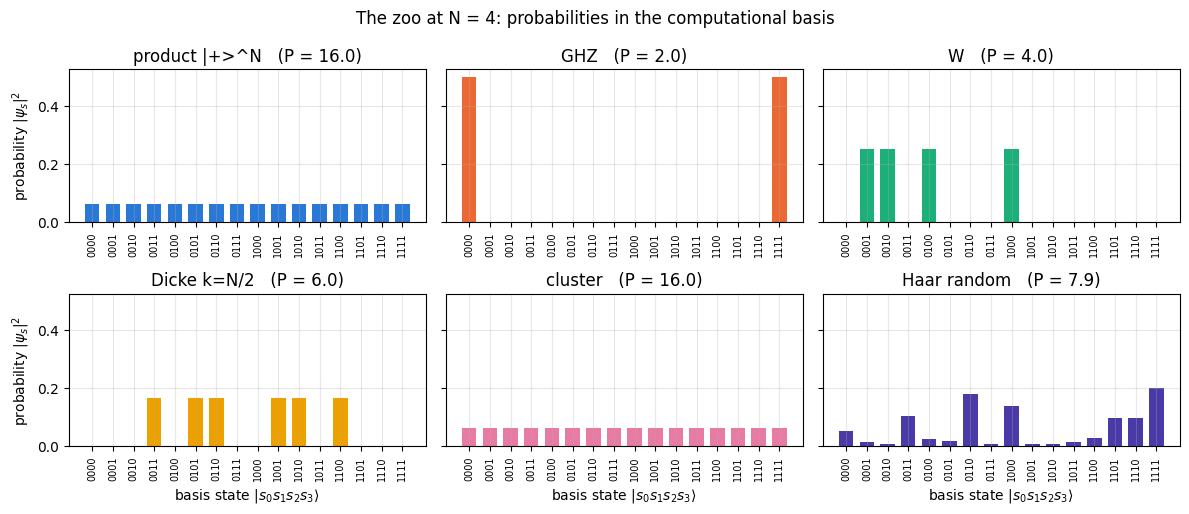

In [10]:
# ==============================================================================
# The zoo: six states that accompany us through the notebook
# ==============================================================================
ZOO_NAMES = ["product |+>^N", "GHZ", "W", "Dicke k=N/2", "cluster", "Haar random"]
ZOO_STYLE = {name: dict(color=c, marker=m) for name, c, m in zip(ZOO_NAMES, PALETTE, MARKERS)}


def make_zoo(N, key=jax.random.PRNGKey(2024)):
    """Dictionary name -> rank-N tensor. The Haar state is reproducible through its explicit key."""
    return {"product |+>^N": product_state("+" * N), "GHZ": ghz_state(N), "W": w_state(N),
            "Dicke k=N/2": dicke_state(N, N // 2), "cluster": cluster_state(N), "Haar random": haar_state(key, N)}


def participation_number(psi):
    """P = 1 / sum_s |psi_s|^4  (inverse of the inverse participation ratio) in the computational basis."""
    return 1.0 / jnp.sum(jnp.abs(psi) ** 4)


zoo4 = make_zoo(4)
labels4 = ["".join(map(str, b)) for b in itertools.product([0, 1], repeat=4)]
fig, axes = plt.subplots(2, 3, figsize=(12, 5.2), sharey=True)
for ax, (name, psi) in zip(axes.ravel(), zoo4.items()):
    ax.bar(range(16), np.abs(np.asarray(psi).reshape(-1)) ** 2, color=ZOO_STYLE[name]["color"], width=0.7)
    ax.set_title(f"{name}   (P = {float(participation_number(psi)):.1f})")
    ax.set_xticks(range(16)); ax.set_xticklabels(labels4, rotation=90, fontsize=7)
for ax in axes[:, 0]:
    ax.set_ylabel(r"probability $|\psi_s|^2$")
for ax in axes[1]:
    ax.set_xlabel(r"basis state $|s_0s_1s_2s_3\rangle$")
fig.suptitle("The zoo at N = 4: probabilities in the computational basis")
fig.tight_layout(); plt.show()

**What we see.** GHZ lives on 2 basis states, W on $N=4$, the Dicke state on $\binom42=6$; the product state
$|{+}\rangle^{\otimes4}$ and the cluster state are *both perfectly flat* ($P=16$); the random state is spread irregularly over everything
($P\approx 2^N/2$; the factor $1/2$ is a property of Gaussian amplitudes discussed in notebook 10).

> **Common pitfall.** Probabilities in one basis say almost nothing about entanglement. The product state $|{+}\rangle^{\otimes N}$
> and the highly entangled cluster state have *identical* histograms — all the difference is in the signs.
> And the participation number is basis dependent: $|{+}\rangle^{\otimes N}$ has $P=2^N$ in the $Z$ basis but $P=1$ in the $X$ basis.
> Tools that look at *parts* of the system are the subject of the next section.

## 3. Reduced density matrices

### 3.1 Theory: what a part of the system can know

Split the spins into a subsystem $A$ (the spins we look at) and the rest $B$. Group the tensor indices accordingly,
$\psi[a,b]$ with $a=(s_q)_{q\in A}$ and $b=(s_q)_{q\in B}$:

$$|\psi\rangle=\sum_{a,b}\psi[a,b]\;|a\rangle_A|b\rangle_B .$$

Take any observable that acts on $A$ only, $O=O_A\otimes\mathbb 1_B$, with matrix elements $O_A[a',a]=\langle a'|O_A|a\rangle$.
Its expectation value is

$$\langle\psi|O_A\otimes\mathbb 1_B|\psi\rangle
  =\sum_{a,a',b,b'}\psi^*[a',b']\;O_A[a',a]\,\delta_{b'b}\;\psi[a,b]
  =\sum_{a,a'}O_A[a',a]\underbrace{\sum_b\psi[a,b]\,\psi^*[a',b]}_{\displaystyle\rho_A[a,a']} .$$

The identity on $B$ produced the Kronecker delta $\delta_{b'b}$, which ties the two $B$ indices together. Recognising
$\sum_{a,a'}O_A[a',a]\rho_A[a,a']=\mathrm{Tr}(O_A\rho_A)$ we arrive at the two central formulas of this notebook:

$$\boxed{\;\rho_A[a,a']=\sum_b\psi[a,b]\,\psi^*[a',b]\;}\qquad(1)\qquad\qquad
  \boxed{\;\langle O_A\rangle=\mathrm{Tr}\,(\rho_A O_A)\;}\qquad(2)$$

$\rho_A$ is the **reduced density matrix** (RDM) of $A$. It is a $2^{|A|}\times2^{|A|}$ matrix — *small* if $A$ is a few
spins, no matter how large $N$ is — and by Eq. (2) it contains **everything** that measurements on $A$ alone can reveal.
In operator language Eq. (1) is the *partial trace* $\rho_A=\mathrm{Tr}_B|\psi\rangle\langle\psi|$ that you met for small
matrices in notebook 02.

**Properties** (each follows from Eq. (1) in one line):

* Hermitian: $\rho_A[a',a]^*=\sum_b\psi^*[a',b]\psi[a,b]=\rho_A[a,a']$;
* unit trace: $\mathrm{Tr}\rho_A=\sum_{a,b}|\psi[a,b]|^2=\langle\psi|\psi\rangle=1$;
* positive semi-definite: $\langle v|\rho_A|v\rangle=\sum_b\big|\sum_a v_a^*\psi[a,b]\big|^2\ge0$ for every vector $v$.

So the eigenvalues $p_k$ of $\rho_A$ are probabilities ($p_k\ge0$, $\sum_kp_k=1$). Any matrix with these three properties is
called a **density matrix**; it describes a *statistical mixture*: "the system is in eigenvector $|k\rangle$ with probability $p_k$".
A pure state $|\phi\rangle$ corresponds to the special case $\rho=|\phi\rangle\langle\phi|$ (one $p_k=1$). Density matrices get
their own lecture in [notebook 07](07_density_matrices_and_quantum_channels.ipynb); here we only need this definition.

> **Physics insight.** Take the Bell state $(|00\rangle+|11\rangle)/\sqrt2$, i.e. $\psi=\mathbb 1/\sqrt2$ as a $2\times2$ array.
> Eq. (1) gives $\rho_A=\psi\psi^\dagger=\mathbb 1/2$: the *maximally mixed* state — a fair coin. The pair is in a perfectly
> known pure state, yet each spin on its own is completely random. This has no classical analogue (complete knowledge of the
> whole, no knowledge of the parts) and it is the defining signature of entanglement.

It is useful to keep a matrix picture in mind: if we reshape the tensor into the matrix $M[a,b]=\psi[a,b]$
($2^{|A|}$ rows, $2^{|B|}$ columns), Eq. (1) reads $\rho_A=MM^\dagger$. We will meet $M$ again in Section 6.

### 3.2 From formula to einsum string for $N=3$

Equation (1) is a contraction of $\psi$ with $\psi^*$ in which

* the indices of $B$ are **shared** by the two tensors and do **not** appear in the output $\Rightarrow$ summed (traced out);
* the indices of $A$ get **different** letters in the two tensors and **both** appear in the output $\Rightarrow$ stay open.

For three spins `psi[a,b,c]`, using capital letters for the primed (bra) indices:

| keep $A$ | formula | einsum string (operands `psi, psi.conj()`) |
|---|---|---|
| spin 0 | $\rho[a,a']=\sum_{b,c}\psi[a,b,c]\psi^*[a',b,c]$ | `"abc,Abc->aA"` |
| spin 1 | $\rho[b,b']=\sum_{a,c}\psi[a,b,c]\psi^*[a,b',c]$ | `"abc,aBc->bB"` |
| spins 0,2 | $\rho[ac,a'c']=\sum_{b}\psi[a,b,c]\psi^*[a',b,c']$ | `"abc,AbC->acAC"` then reshape `(2,2,2,2)->(4,4)` |

In the last line the output has four open legs; grouping $(a,c)$ into a row index and $(a',c')$ into a column index is a
`reshape` (C-ordering: the first kept spin is the most significant bit of the small matrix).

**The independent reference.** To test these strings we need a partial trace that shares *no code and no idea* with
them. We use the definition literally: build the full projector $|\psi\rangle\langle\psi|$ as a $2^N\times2^N$ matrix and
sum its entries over the bits of $B$ with explicit Python loops over bit strings and the flat-index formula
$i=\sum_qs_q2^{N-1-q}$. Slow, transparent, obviously correct — the ideal referee.

In [11]:
# ==============================================================================
# DENSE REFERENCE: partial trace by explicit loops over bit strings (validation only!)
# ==============================================================================
def partial_trace_reference(rho_mat, keep, N):
    """rho_A[a,a'] = sum_b rho[(a,b),(a',b)] with explicit loops and the flat-index formula.
    rho_mat: dense 2^N x 2^N matrix.  Cost O(4^|A| 2^|B|) Python iterations -- tiny N only."""
    rho_mat = np.asarray(rho_mat)
    keep = list(keep)
    rest = [q for q in range(N) if q not in keep]

    def flat_index(bits_keep, bits_rest):
        bits = [0] * N
        for q, s in zip(keep, bits_keep):
            bits[q] = s
        for q, s in zip(rest, bits_rest):
            bits[q] = s
        return sum(s << (N - 1 - q) for q, s in enumerate(bits))       # spin 0 = most significant bit

    dA = 2 ** len(keep)
    out = np.zeros((dA, dA), dtype=complex)
    for ia, a in enumerate(itertools.product([0, 1], repeat=len(keep))):
        for ja, a2 in enumerate(itertools.product([0, 1], repeat=len(keep))):
            for b in itertools.product([0, 1], repeat=len(rest)):
                out[ia, ja] += rho_mat[flat_index(a, b), flat_index(a2, b)]
    return out


def projector_dense(psi):
    """|psi><psi| as a dense 2^N x 2^N matrix (validation only)."""
    v = np.asarray(psi).reshape(-1)
    return np.outer(v, v.conj())

In [12]:
# ==============================================================================
# STEP 1: hand-written einsum strings for N = 3, tested on a random state
# ==============================================================================
psi3 = haar_state(jax.random.PRNGKey(3), 3)          # a generic state: no accidental symmetries hide bugs
P3 = projector_dense(psi3)

rho_0 = jnp.einsum("abc,Abc->aA", psi3, psi3.conj())
rho_1 = jnp.einsum("abc,aBc->bB", psi3, psi3.conj())
rho_02 = jnp.einsum("abc,AbC->acAC", psi3, psi3.conj()).reshape(4, 4)

for label, rho, keep in (("keep (0,)", rho_0, (0,)), ("keep (1,)", rho_1, (1,)), ("keep (0,2)", rho_02, (0, 2))):
    err = max_abs(rho - partial_trace_reference(P3, keep, 3))
    print(f"CHECKPOINT {label:11s}: shape {rho.shape}, trace = {float(jnp.trace(rho).real):.12f}, "
          f"max error vs loop reference = {err:.1e}")
    assert err < TOL

print("\nrho of spin 0 (a 2x2 Hermitian matrix with unit trace):")
print(np.round(np.asarray(rho_0), 4))

CHECKPOINT keep (0,)  : shape (2, 2), trace = 1.000000000000, max error vs loop reference = 5.6e-17
CHECKPOINT keep (1,)  : shape (2, 2), trace = 1.000000000000, max error vs loop reference = 5.6e-17


CHECKPOINT keep (0,2) : shape (4, 4), trace = 1.000000000000, max error vs loop reference = 2.8e-17

rho of spin 0 (a 2x2 Hermitian matrix with unit trace):
[[ 0.3048+0.j     -0.1065-0.2127j]
 [-0.1065+0.2127j  0.6952+0.j    ]]


All three strings reproduce the loop reference to machine precision, the traces are 1 and the printed $2\times2$ matrix is
Hermitian. What the einsum did **not** do matters as much: it never formed the $8\times8$ projector, but contracted two
rank-3 tensors directly into a $2\times2$ result.

### 3.3 The einsum string for arbitrary $N$ and `keep`

For arbitrary $N$ and an arbitrary list `keep` we generate the string programmatically, exactly as we did for
`apply_gate` in notebook 05:

1. label the axes of $\psi$ with the first $N$ letters: `a = ['a','b','c',...]`;
2. copy the list for $\psi^*$ and replace the letters of the kept spins by *fresh* letters (the next unused ones);
3. output = kept letters of $\psi$ (in the order of `keep`) followed by the fresh letters in the same order;
4. run the einsum on `psi, psi.conj()` and reshape the $2k$ open legs into a $2^k\times2^k$ matrix.

The order of `keep` defines the order of the spins inside the small matrix: `keep=(2,0)` makes spin 2 the most
significant bit.

In [13]:
# ==============================================================================
# STEP 2: reduced density matrix for any N and any subsystem -- string built programmatically
# ==============================================================================
def my_rdm(psi, keep, verbose=False):
    """rho_A = Tr_B |psi><psi| for the spins `keep` of a pure state.

    MATH            rho_A[a,a'] = sum_b psi[a,b] psi^*[a',b]
    IMPLEMENTATION  one einsum; B letters shared (summed), A letters fresh in the second operand (open).
    COST            O(2^N 2^|A|) time, O(2^N + 4^|A|) memory -- the 4^N projector is never formed.
    JAX             `keep` must be static Python ints (they define the string); psi is traced.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    ket = list(_LETTERS[:n])                           # 1. labels of psi
    bra = ket.copy()
    for fresh, q in zip(_LETTERS[n:n + k], keep):      # 2. fresh labels on the kept axes of psi^*
        bra[q] = fresh
    out = "".join(ket[q] for q in keep) + "".join(bra[q] for q in keep)   # 3. open legs: A of psi, then A of psi^*
    sub = f"{''.join(ket)},{''.join(bra)}->{out}"
    if verbose:
        print(f"   N={n}, keep={keep}:  einsum string  '{sub}'")
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)  # 4. legs -> matrix


print("Generated strings (fresh letters are simply the next unused lowercase letters):")
_ = my_rdm(psi3, (0,), verbose=True)
_ = my_rdm(psi3, (0, 2), verbose=True)
psi6 = haar_state(jax.random.PRNGKey(6), 6)
_ = my_rdm(psi6, (4, 1), verbose=True)

Generated strings (fresh letters are simply the next unused lowercase letters):
   N=3, keep=(0,):  einsum string  'abc,dbc->ad'
   N=3, keep=(0, 2):  einsum string  'abc,dbe->acde'
   N=6, keep=(4, 1):  einsum string  'abcdef,ahcdgf->ebgh'


Compare with the hand-written strings: `'abc,dbc->ad'` is our `"abc,Abc->aA"` with the fresh letter `d` playing the role
of `A`. Now the systematic test: every subsystem size, non-contiguous subsystems, permuted order — all against the loop
reference for $N=6$.

In [14]:
# ==============================================================================
# CHECKPOINT: my_rdm vs loop reference for many subsystems of a random 6-spin state
# ==============================================================================
P6 = projector_dense(psi6)
worst = 0.0
for keep in [(0,), (5,), (2, 3), (0, 5), (4, 1), (1, 3, 5), (5, 0, 2), (0, 1, 2, 3)]:
    rho = my_rdm(psi6, keep)
    err = max_abs(rho - partial_trace_reference(P6, keep, 6))
    herm = max_abs(rho - rho.conj().T)
    pmin = float(jnp.linalg.eigvalsh(rho)[0])
    worst = max(worst, err)
    print(f"keep={str(keep):13s} error = {err:.1e} | Hermiticity = {herm:.1e} | trace = {float(jnp.trace(rho).real):.10f}"
          f" | smallest eigenvalue = {pmin:+.2e}")
    assert err < TOL and herm < TOL and pmin > -TOL
print(f"\nworst error over all subsystems: {worst:.1e}")

keep=(0,)          error = 1.1e-16 | Hermiticity = 0.0e+00 | trace = 1.0000000000 | smallest eigenvalue = +3.65e-01
keep=(5,)          error = 1.1e-16 | Hermiticity = 0.0e+00 | trace = 1.0000000000 | smallest eigenvalue = +3.54e-01


keep=(2, 3)        error = 2.8e-17 | Hermiticity = 0.0e+00 | trace = 1.0000000000 | smallest eigenvalue = +8.25e-02
keep=(0, 5)        error = 5.6e-17 | Hermiticity = 0.0e+00 | trace = 1.0000000000 | smallest eigenvalue = +9.65e-02
keep=(4, 1)        error = 5.6e-17 | Hermiticity = 0.0e+00 | trace = 1.0000000000 | smallest eigenvalue = +7.79e-02


keep=(1, 3, 5)     error = 5.6e-17 | Hermiticity = 0.0e+00 | trace = 1.0000000000 | smallest eigenvalue = +1.54e-03
keep=(5, 0, 2)     error = 2.8e-17 | Hermiticity = 0.0e+00 | trace = 1.0000000000 | smallest eigenvalue = +2.93e-04


keep=(0, 1, 2, 3)  error = 2.8e-17 | Hermiticity = 0.0e+00 | trace = 1.0000000000 | smallest eigenvalue = -1.13e-16

worst error over all subsystems: 1.1e-16


Every reduced matrix is Hermitian, has unit trace and no negative eigenvalue (up to rounding), and agrees with the
reference. In the case `keep=(0,1,2,3)` the RDM of 4 out of 6 spins is a $16\times16$ matrix of rank at most $4$
(its smallest eigenvalues are zero up to rounding) — we will understand why in Section 6.

### 3.4 Partial trace of a density tensor: a repeated letter inside one operand

Sometimes the *global* state is already mixed (noise, loss, imperfect preparation — notebook 07). An $N$-spin density matrix
$\rho$ is a $2^N\times2^N$ matrix; in this course we store it as a **density tensor** of rank $2N$,

$$\rho[s_0,\dots,s_{N-1};\,s'_0,\dots,s'_{N-1}],$$

with the $N$ *ket* axes first and the $N$ *bra* axes after them (for a pure state $\rho=\psi\otimes\psi^*$, an outer
product, `to_dm`). The partial trace over spin $q$ sets $s_q=s'_q$ and sums. In einsum language this is the third
elementary rule in action — **the same letter twice inside a single operand, absent from the output, is a trace** (exactly like `"ii->"`):

| $N$ | keep | einsum string (single operand `rho`) |
|---|---|---|
| 2 | spin 0 | `"abAb->aA"` |
| 3 | spin 0 | `"abcAbc->aA"` |
| 3 | spins 0,2 | `"abcAbC->acAC"` |

In [15]:
# ==============================================================================
# STEP 3: partial trace of a density tensor -- by hand, then general
# ==============================================================================
def my_rdm_dm(rho, keep):
    """Partial trace of a rank-2N density tensor, keeping the spins `keep`.
    MATH    rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM  ket letters a,b,c,...; bra letters: FRESH for kept spins, the SAME letter for traced spins."""
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# a genuinely MIXED global state of 3 spins: 70% GHZ + 30% W  (a convex mixture of two projectors)
rho_mix = 0.7 * to_dm(ghz_state(3)) + 0.3 * to_dm(w_state(3))          # rank-6 tensor of shape (2,)*6
print("density tensor shape:", rho_mix.shape, "| trace =", float(jnp.trace(dm_matrix(rho_mix)).real))

by_hand = jnp.einsum("abcAbC->acAC", rho_mix).reshape(4, 4)             # keep spins (0,2)
reference = partial_trace_reference(dm_matrix(rho_mix), (0, 2), 3)
print(f"CHECKPOINT by-hand string  vs loop reference: {max_abs(by_hand - reference):.1e}")
print(f"CHECKPOINT general my_rdm_dm vs loop reference: {max_abs(my_rdm_dm(rho_mix, (0, 2)) - reference):.1e}")
assert max_abs(by_hand - reference) < TOL and max_abs(my_rdm_dm(rho_mix, (0, 2)) - reference) < TOL

# consistency of the two routes for a pure state, and "tracing in two steps = tracing at once"
err_routes = max_abs(my_rdm_dm(to_dm(psi6), (1, 4)) - my_rdm(psi6, (1, 4)))
two_steps = partial_trace_reference(my_rdm(psi6, (1, 2, 4)), (0, 2), 3)   # spins (1,2,4) -> drop the middle one
err_steps = max_abs(two_steps - my_rdm(psi6, (1, 4)))
print(f"CHECKPOINT rdm_dm(|psi><psi|) == rdm(psi): {err_routes:.1e} | two-step trace == one-step trace: {err_steps:.1e}")
assert err_routes < TOL and err_steps < TOL

density tensor shape: (2, 2, 2, 2, 2, 2) | trace = 0.9999999999999998
CHECKPOINT by-hand string  vs loop reference: 0.0e+00


CHECKPOINT general my_rdm_dm vs loop reference: 0.0e+00


CHECKPOINT rdm_dm(|psi><psi|) == rdm(psi): 5.6e-17 | two-step trace == one-step trace: 5.6e-17


> **Numerical practice.** For a pure state always use the first route. `my_rdm_dm(to_dm(psi), ...)` gives the same
> matrix but needs the full density tensor: $4^N$ numbers. At $N=14$ this is $4^{14}\times16$ bytes $\approx 4.3$ GB versus
> $0.26$ MB for the state tensor; at $N=20$ it is 17.6 TB. Equation (1) costs $O(2^N2^{|A|})$ and never leaves the world of $2^N$.

Here are the production versions. They are our functions without the `verbose` switch.

In [16]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


In [17]:
# CHECKPOINT: engine versions == the functions we derived
for keep in [(0,), (4, 1), (1, 3, 5)]:
    assert max_abs(rdm(psi6, keep) - my_rdm(psi6, keep)) < TOL
assert max_abs(rdm_dm(rho_mix, (0, 2)) - my_rdm_dm(rho_mix, (0, 2))) < TOL
print("engine rdm / rdm_dm agree with the hand-derived versions.")

engine rdm / rdm_dm agree with the hand-derived versions.


## 4. Local observables, correlations and Pauli strings

### 4.1 Expectation values from the RDM

Equation (2), $\langle O_A\rangle=\mathrm{Tr}(\rho_AO_A)$, is a two-line function: compute the small RDM, multiply by the
small operator, take the trace. Since an expectation value of a Hermitian operator is real, we return the real part
(the imaginary part is rounding noise).

The dense reference is the textbook formula of notebook 03: embed the operator with a Kronecker chain,
$O_q=\mathbb 1\otimes\dots\otimes O\otimes\dots\otimes\mathbb 1$, and evaluate $\langle\psi|O_q|\psi\rangle$ with $2^N\times2^N$ matrices.

In [18]:
# ==============================================================================
# STEP 1: <O> = Tr(rho_A O), validated against kron-embedded dense operators
# ==============================================================================
def my_expect_local(psi, O, qubits):
    """<psi|O_qubits|psi> = Tr(rho_A O) for a k-local operator O (2^k x 2^k matrix), A = `qubits`."""
    return jnp.real(jnp.trace(my_rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))


def dense_expect(psi, ops_by_site):
    """Reference: <psi| (x)_q O_q |psi> with a dense kron chain. ops_by_site: dict {site: 2x2 matrix}."""
    N = psi.ndim
    big = kron_chain([ops_by_site.get(q, np.eye(2)) for q in range(N)])
    v = np.asarray(psi).reshape(-1)
    return float(np.real(v.conj() @ big @ v))


tests = [("<X_2>", X, (2,), {2: X}), ("<Y_0>", Y, (0,), {0: Y}), ("<Z_5>", Z, (5,), {5: Z}),
         ("<Z_1 Z_4>", ZZ, (1, 4), {1: Z, 4: Z}), ("<X_4 Y_1>", jnp.kron(X, Y), (4, 1), {4: X, 1: Y})]
for label, O, qubits, dense in tests:
    val, ref = float(my_expect_local(psi6, O, qubits)), dense_expect(psi6, dense)
    print(f"CHECKPOINT {label:10s}: einsum/RDM = {val:+.10f}   dense kron = {ref:+.10f}   |diff| = {abs(val - ref):.1e}")
    assert abs(val - ref) < TOL

CHECKPOINT <X_2>     : einsum/RDM = -0.0277953524   dense kron = -0.0277953524   |diff| = 1.4e-17
CHECKPOINT <Y_0>     : einsum/RDM = -0.2035967042   dense kron = -0.2035967042   |diff| = 5.6e-17
CHECKPOINT <Z_5>     : einsum/RDM = -0.1681393583   dense kron = -0.1681393583   |diff| = 0.0e+00


CHECKPOINT <Z_1 Z_4> : einsum/RDM = +0.0469475122   dense kron = +0.0469475122   |diff| = 4.2e-17
CHECKPOINT <X_4 Y_1> : einsum/RDM = +0.1049795415   dense kron = +0.1049795415   |diff| = 2.8e-17


In the last test, `qubits=(4,1)` with the operator `kron(X, Y)` means "$X$ on spin 4, $Y$ on spin 1" — the **first listed
spin is the left factor of the Kronecker product**, the same convention as in `apply_gate`.

### 4.2 Bloch vectors of the zoo: GHZ looks like noise

A single-spin RDM is a $2\times2$ density matrix and can always be written as

$$\rho_q=\tfrac12\big(\mathbb 1+r_xX+r_yY+r_zZ\big),\qquad r_\alpha=\langle\sigma^\alpha_q\rangle=\mathrm{Tr}(\rho_q\sigma^\alpha),$$

because the Pauli matrices together with $\mathbb 1$ form a basis of Hermitian $2\times2$ matrices and
$\mathrm{Tr}(\sigma^\alpha\sigma^\beta)=2\delta_{\alpha\beta}$. The **Bloch vector** $\vec r$ has length $|\vec r|\le1$; the
eigenvalues of $\rho_q$ are $(1\pm|\vec r|)/2$. So $|\vec r|=1$ means the spin is in a pure state — *not entangled with
anything* — while $|\vec r|<1$ means it is mixed, and for a globally pure state the only possible reason is entanglement
with the other spins. One RDM serves all three components: one einsum, three tiny traces.

In [19]:
# ==============================================================================
# STEP 2: Bloch vector of spin 0 for every state of the zoo (N = 8)
# ==============================================================================
N = 8
zoo = make_zoo(N)
print(f"{'state':16s} {'<X_0>':>8s} {'<Y_0>':>8s} {'<Z_0>':>8s} {'|r|':>8s}   interpretation")
for name, psi in zoo.items():
    rho_q = rdm(psi, (0,))                                            # ONE einsum ...
    r = np.array([float(jnp.trace(rho_q @ P).real) for P in (X, Y, Z)])   # ... three 2x2 traces
    length = np.linalg.norm(r)
    verdict = "pure: spin 0 is NOT entangled" if length > 1 - 1e-6 else (
        "maximally mixed: a fair coin" if length < 1e-6 else "partially mixed")
    print(f"{name:16s} {r[0]:+8.4f} {r[1]:+8.4f} {r[2]:+8.4f} {length:8.4f}   {verdict}")

state               <X_0>    <Y_0>    <Z_0>      |r|   interpretation
product |+>^N     +1.0000  +0.0000  +0.0000   1.0000   pure: spin 0 is NOT entangled
GHZ               +0.0000  +0.0000  +0.0000   0.0000   maximally mixed: a fair coin
W                 +0.0000  +0.0000  +0.7500   0.7500   partially mixed
Dicke k=N/2       +0.0000  +0.0000  +0.0000   0.0000   maximally mixed: a fair coin
cluster           +0.0000  +0.0000  +0.0000   0.0000   maximally mixed: a fair coin
Haar random       -0.0392  -0.0382  +0.0138   0.0564   partially mixed


* The product state has $|\vec r|=1$ (pointing along $+x$), as it must.
* **GHZ, Dicke ($k=N/2$) and the cluster state have $\vec r=0$ exactly**: every single spin is a fair coin. Looking at one
  spin you cannot distinguish these three very different states from each other, nor from pure noise.
* W has $\langle Z\rangle=1-2/N=0.75$: each spin is "up" except for the $1/N$ chance of hosting the excitation.
* The random state has a small but non-zero Bloch vector, of the order $2^{-N/2}$: for any Pauli string $P\neq\mathbb 1$ the Haar
  average of $\langle P\rangle$ is $0$ and its variance is $(\mathrm{Tr}P^2)/(D(D+1))=1/(2^N+1)$.

> **Physics insight.** In an entangled state the information is stored *between* the parts, in correlations.
> To tell GHZ, Dicke and cluster apart we must look at two or more spins at a time.

### 4.3 Two-point correlators and correlation matrices

The **correlator** of two spins is $\langle\sigma^\alpha_i\sigma^\alpha_j\rangle$, a 2-local observable:
`expect_local(psi, ZZ, (i, j))`. A large value alone is not yet evidence of correlation — in the product state
$|00\dots0\rangle$ one has $\langle Z_iZ_j\rangle=1$ simply because each $\langle Z_i\rangle=1$. What measures correlation is the
**connected correlator**

$$C^{\alpha}_{ij}=\langle\sigma^\alpha_i\sigma^\alpha_j\rangle-\langle\sigma^\alpha_i\rangle\langle\sigma^\alpha_j\rangle,$$

the covariance of the two measurement outcomes. For any product state $\rho_{ij}=\rho_i\otimes\rho_j$, hence
$\langle\sigma_i\sigma_j\rangle=\mathrm{Tr}(\rho_i\sigma)\mathrm{Tr}(\rho_j\sigma)$ and $C_{ij}=0$ identically.

**From formula to code, two ways.**

* *The general way*: a double loop over pairs $(i,j)$ calling `expect_local`. Each pair is a different einsum string, so this
  is a Python loop over $N(N-1)/2$ small contractions of cost $O(2^N)$ each. It works for any operator.
* *The fast way for diagonal operators*: $Z_iZ_j$ is diagonal in the computational basis, so
  $\langle Z_iZ_j\rangle=\sum_s|\psi_s|^2z_i(s)z_j(s)$ with $z_q(s)=1-2s_q=\pm1$. Store the signs in a table `z[s, q]` of shape
  $(2^N,N)$ and the whole matrix is **one einsum**, `"s,si,sj->ij"`. For $XX$ correlators first rotate every spin
  with the Hadamard matrix ($HXH=Z$: the $X$ basis becomes the computational basis), then reuse the same code. Because this
  version has no Python loop over static indices, it can be `jit`-compiled once and `vmap`-ed over a batch of states.

In [20]:
# ==============================================================================
# STEP 3: correlation matrices -- general loop version and the one-einsum version
# ==============================================================================
def correlation_matrix_loop(psi, P):
    """M_ij = <P_i P_j> (i != j; M_ii = 1, valid for P^2 = 1, i.e. Pauli operators) and m_i = <P_i>, via `expect_local`."""
    N = psi.ndim
    PP = jnp.kron(P, P)
    m = np.array([float(my_expect_local(psi, P, (i,))) for i in range(N)])
    M = np.eye(N)
    for i in range(N):
        for j in range(i + 1, N):
            M[i, j] = M[j, i] = float(my_expect_local(psi, PP, (i, j)))
    return M, m


def sign_table(N):
    """z[s, q] = 1 - 2 s_q = eigenvalue of Z_q on the basis state with flat index s  (shape (2^N, N)).
    Bits are unpacked with shifts: s_q = (s >> (N-1-q)) & 1  (spin 0 = most significant bit)."""
    s = jnp.arange(2 ** N)
    bits = (s[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1
    return (1 - 2 * bits).astype(RDTYPE)


def zz_matrix_fast(psi):
    """All <Z_i Z_j> at once:  M_ij = sum_s p(s) z_i(s) z_j(s)  -- einsum 's,si,sj->ij'. Returns (M, m)."""
    N = psi.ndim
    p = jnp.abs(psi.reshape(-1)) ** 2
    z = sign_table(N)
    return jnp.einsum("s,si,sj->ij", p, z, z), jnp.einsum("s,si->i", p, z)


def xx_matrix_fast(psi):
    """All <X_i X_j>: rotate every spin with H (H X H = Z), then the problem is diagonal again."""
    for q in range(psi.ndim):
        psi = apply_gate(psi, H, [q])
    return zz_matrix_fast(psi)


def connected(M, m):
    """C_ij = <P_i P_j> - <P_i><P_j>."""
    return M - np.outer(m, m)


# --- CHECKPOINT on a random state: the two routes agree, and agree with dense kron ------------------
psi_r = zoo["Haar random"]
M_loop, m_loop = correlation_matrix_loop(psi_r, Z)
M_fast, m_fast = zz_matrix_fast(psi_r)
Mx_loop, _ = correlation_matrix_loop(psi_r, X)
Mx_fast, _ = xx_matrix_fast(psi_r)
print(f"CHECKPOINT ZZ matrix  loop vs one-einsum : {max_abs(M_loop - M_fast):.1e}")
print(f"CHECKPOINT XX matrix  loop vs one-einsum : {max_abs(Mx_loop - Mx_fast):.1e}")
print(f"CHECKPOINT <Z_2 Z_6>  vs dense kron      : {abs(M_fast[2, 6] - dense_expect(psi_r, {2: Z, 6: Z})):.1e}")
assert max_abs(M_loop - M_fast) < TOL and max_abs(Mx_loop - Mx_fast) < TOL
assert abs(M_fast[2, 6] - dense_expect(psi_r, {2: Z, 6: Z})) < TOL

CHECKPOINT ZZ matrix  loop vs one-einsum : 2.2e-16
CHECKPOINT XX matrix  loop vs one-einsum : 1.7e-15


CHECKPOINT <Z_2 Z_6>  vs dense kron      : 2.1e-17


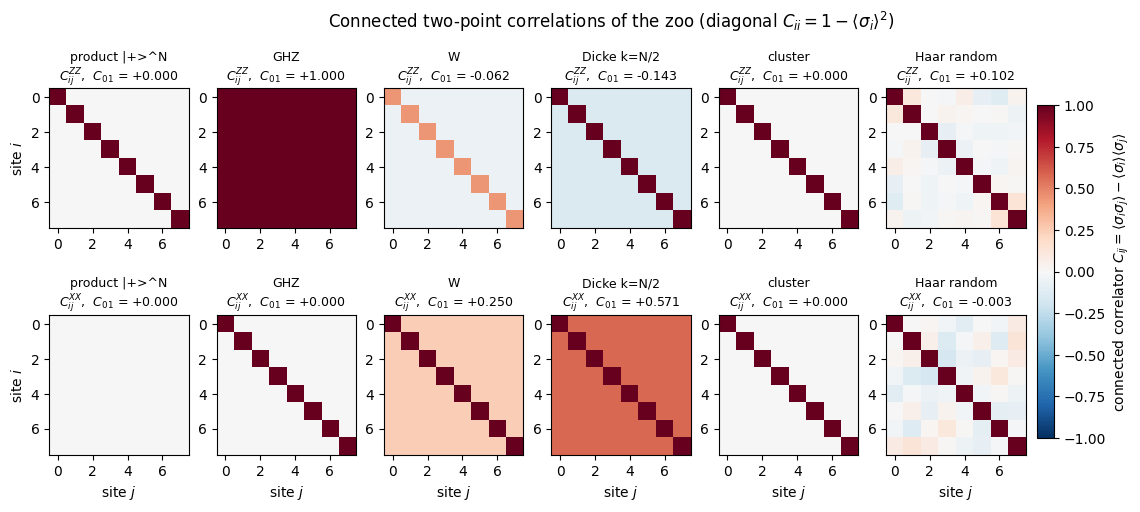

CHECKPOINT W     : C^ZZ_01 = -0.062500   analytic -4/N^2   = -0.062500
CHECKPOINT Dicke : C^ZZ_01 = -0.142857   analytic -1/(N-1) = -0.142857


In [21]:
# ==============================================================================
# FIGURE: connected ZZ and XX correlation matrices of the zoo (N = 8)
# ==============================================================================
fig, axes = plt.subplots(2, 6, figsize=(15, 5.4))
for col, (name, psi) in enumerate(zoo.items()):
    for row, (fast, lab) in enumerate(((zz_matrix_fast, "ZZ"), (xx_matrix_fast, "XX"))):
        M, m = fast(psi)
        C = connected(np.asarray(M), np.asarray(m))
        ax = axes[row, col]
        im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)       # diverging map, neutral midpoint at 0
        c01 = C[0, 1] if abs(C[0, 1]) > 5e-4 else 0.0                # avoid printing "-0.000"
        ax.set_title(f"{name}\n$C^{{{lab}}}_{{ij}}$,  $C_{{01}}$ = {c01:+.3f}", fontsize=9)
        ax.set_xticks(range(0, N, 2)); ax.set_yticks(range(0, N, 2)); ax.grid(False)
        if col == 0:
            ax.set_ylabel("site $i$")
        if row == 1:
            ax.set_xlabel("site $j$")
cb = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.01)
cb.set_label(r"connected correlator $C_{ij}=\langle\sigma_i\sigma_j\rangle-\langle\sigma_i\rangle\langle\sigma_j\rangle$")
fig.suptitle("Connected two-point correlations of the zoo (diagonal $C_{ii}=1-\\langle\\sigma_i\\rangle^2$)")
plt.show()

# analytic values for the W and Dicke states (derived in the text below)
Cw = connected(*map(np.asarray, zz_matrix_fast(zoo["W"])))[0, 1]
Cd = connected(*map(np.asarray, zz_matrix_fast(zoo["Dicke k=N/2"])))[0, 1]
print(f"CHECKPOINT W     : C^ZZ_01 = {Cw:+.6f}   analytic -4/N^2   = {-4 / N ** 2:+.6f}")
print(f"CHECKPOINT Dicke : C^ZZ_01 = {Cd:+.6f}   analytic -1/(N-1) = {-1 / (N - 1):+.6f}")
assert abs(Cw + 4 / N ** 2) < TOL and abs(Cd + 1 / (N - 1)) < TOL

**Reading the figure** (top row $ZZ$, bottom row $XX$; the diagonal is $1-\langle\sigma_i\rangle^2$ and carries no information about pairs).

* **Product state**: no off-diagonal correlations at all (the $XX$ diagonal also vanishes because $\langle X_i\rangle=1$).
* **GHZ**: $C^{ZZ}_{ij}=+1$ for *all* pairs, at any distance — if one spin is found up, all are. But $C^{XX}=0$: the two-spin RDM
  of GHZ is the classical mixture $\tfrac12(|00\rangle\langle00|+|11\rangle\langle11|)$; what makes GHZ quantum is invisible to two-point functions.
* **W**: weak *negative* $ZZ$ correlations. Derivation: $\langle Z_i\rangle=1-2/N$ and $\langle Z_iZ_j\rangle=1-4/N$ (the product is $-1$ only if the
  excitation sits on $i$ or on $j$), so $C^{ZZ}_{ij}=1-4/N-(1-2/N)^2=-4/N^2$ — finding the excitation here means it is not there.
  The coherence of the superposition shows up as $\langle X_iX_j\rangle=2/N>0$.
* **Dicke $k=N/2$**: $C^{ZZ}_{ij}=-1/(N-1)$. Derivation: $\big(\sum_iZ_i\big)^2=0$ on this state (zero total magnetisation), so
  $N+N(N-1)\langle Z_iZ_j\rangle=0$. The $XX$ correlations are large and positive: the collective spin is long and lies in the $xy$ plane.
* **Cluster**: every connected $ZZ$ and $XX$ correlator vanishes, and we saw that all Bloch vectors vanish too. In the *bulk* of the chain
  the two-spin reduced state is exactly $\mathbb 1/4$, so no two-spin measurement whatsoever distinguishes the cluster state from white noise;
  its correlations sit in three-body operators (next subsection). The two spins at each **end** are the exception: $\langle X_0Z_1\rangle=+1$
  and $\langle Z_{N-2}X_{N-1}\rangle=+1$, because the end stabilisers $X_0Z_1$ and $Z_{N-2}X_{N-1}$ are two-body. A mixed $XZ$ correlator is
  not plotted above, which is why the figure shows nothing there.
* **Random state**: only a faint random speckle of order $2^{-N/2}\approx0.06$ (the variance $1/(2^N+1)$ of Section 4.2), with no structure.

> **JAX practice.** `zz_matrix_fast` is a pure function of the state tensor with no Python loop, so `jax.vmap` lifts it to a
> whole *batch* of states, and `jax.jit` compiles the batch computation into one XLA program. Below: the typical size of
> correlations in random states, averaged over 200 samples, as a function of $N$ — a loop over states would be much slower.

In [22]:
# ==============================================================================
# STEP 4: vmap over a batch of random states -- typical correlations in Haar states
# ==============================================================================
def typical_offdiag_correlation(keys, N):
    """Root-mean-square connected ZZ correlator over pairs i != j and over a batch of Haar states."""
    def one(key):
        M, m = zz_matrix_fast(haar_state(key, N))
        C = M - jnp.outer(m, m)
        off = C - jnp.diag(jnp.diag(C))
        return jnp.sum(off ** 2) / (N * (N - 1))
    return jnp.sqrt(jnp.mean(jax.vmap(one)(keys)))


keys = jax.random.split(jax.random.PRNGKey(11), 200)
print(f"{'N':>3s} {'rms C_ij (200 Haar states)':>28s} {'2^(-N/2)':>12s}")
for n in (4, 6, 8, 10, 12):
    rms = float(jax.jit(partial(typical_offdiag_correlation, N=n))(keys))
    print(f"{n:3d} {rms:28.5f} {2 ** (-n / 2):12.5f}")

  N   rms C_ij (200 Haar states)     2^(-N/2)


  4                      0.21708      0.25000


  6                      0.12332      0.12500


  8                      0.06154      0.06250


 10                      0.03084      0.03125


 12                      0.01566      0.01562


The typical two-point correlation in a random state follows $2^{-N/2}$ closely: it is *exponentially small* in the system size. Random states are extremely
entangled (Section 8), yet they have no visible few-body correlations — the opposite extreme from GHZ, whose $ZZ$ correlations are maximal for every pair.

### 4.4 Pauli strings: observables on many spins

A **Pauli string** is a tensor product of Pauli matrices, e.g. $P=X_0Z_1Y_2$ or the $N$-body operator $X^{\otimes N}$. The RDM route is
inappropriate for long strings: for weight $k$ it needs a $2^k\times2^k$ matrix, and for $k=N$ we would be back at $4^N$. Instead use

$$\langle\psi|P|\psi\rangle=\langle\psi|\big(P|\psi\rangle\big):$$

apply the single-spin factors one after another with `apply_gate` (each costs $O(2^N)$), then take **one inner product**.
`jnp.vdot(a, b)` computes $\sum_s a_s^*b_s$ — it conjugates its first argument and flattens the tensors. Cost: $O(k\,2^N)$ for weight $k$.
By hand for $N=3$ and $P=X_0Z_1Y_2$ this is three einsums, `"Aa,abc->Abc"`, `"Bb,abc->aBc"`, `"Cc,abc->abC"`, and a `vdot`.

In [23]:
# ==============================================================================
# STEP 5: Pauli-string expectation values, by hand for N=3 and in general
# ==============================================================================
phi = jnp.einsum("Aa,abc->Abc", X, psi3)             # X on spin 0
phi = jnp.einsum("Bb,abc->aBc", Z, phi)              # Z on spin 1
phi = jnp.einsum("Cc,abc->abC", Y, phi)              # Y on spin 2
by_hand = float(jnp.real(jnp.vdot(psi3, phi)))       # <psi|phi> ; vdot conjugates its first argument
ref = dense_expect(psi3, {0: X, 1: Z, 2: Y})
print(f"CHECKPOINT <X0 Z1 Y2>, N=3: by hand = {by_hand:+.10f} | dense kron = {ref:+.10f} | diff = {abs(by_hand - ref):.1e}")
assert abs(by_hand - ref) < TOL


def my_expect_pauli_string(psi, string):
    """<psi|P|psi> for a Pauli string given as text, one letter per spin, e.g. 'XIZY' ('I' = identity, skipped).
    MATH  <P> = <psi|(P psi)>:  apply the factors with apply_gate, then ONE inner product.   COST O(weight * 2^N)."""
    phi = psi
    for q, letter in enumerate(string):
        if letter != "I":
            phi = apply_gate(phi, PAULI[letter], [q])
    return jnp.real(jnp.vdot(psi, phi))


for string in ("XZYIII", "IZIIZI", "XXXXXX", "YIXZIY"):
    val = float(my_expect_pauli_string(psi6, string))
    ref = dense_expect(psi6, {q: PAULI[c] for q, c in enumerate(string) if c != "I"})
    print(f"CHECKPOINT <{string}> = {val:+.10f}   dense: {ref:+.10f}   diff = {abs(val - ref):.1e}")
    assert abs(val - ref) < TOL

CHECKPOINT <X0 Z1 Y2>, N=3: by hand = +0.1249039720 | dense kron = +0.1249039720 | diff = 4.2e-17


CHECKPOINT <XZYIII> = -0.0942762237   dense: -0.0942762237   diff = 1.4e-17
CHECKPOINT <IZIIZI> = +0.0469475122   dense: +0.0469475122   diff = 6.9e-18


CHECKPOINT <XXXXXX> = +0.1596927841   dense: +0.1596927841   diff = 2.8e-17
CHECKPOINT <YIXZIY> = -0.1611853408   dense: -0.1611853408   diff = 5.6e-17


The production versions, including `all_local_expectations` which returns all $N$ Bloch vectors:

In [24]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))

def all_local_expectations(psi):
    """Bloch vectors of all qubits: array (N,3) with rows (<X_q>, <Y_q>, <Z_q>), from the 1-qubit RDMs."""
    out = []
    for q in range(psi.ndim):
        r = rdm(psi, [q])
        out.append(jnp.stack([jnp.real(jnp.trace(r @ P)) for P in (X, Y, Z)]))
    return jnp.stack(out)


**Where GHZ and cluster states hide their correlations.** Now we can find what one- and two-spin measurements missed.

* For GHZ the operator $X^{\otimes N}$ flips all spins, $|0\dots0\rangle\leftrightarrow|1\dots1\rangle$, so $\langle X^{\otimes N}\rangle=+1$: a *genuine
  $N$-body* correlation. Replacing two $X$ by $Y$ gives $-1$ (since $Y|0\rangle=i|1\rangle$, $Y|1\rangle=-i|0\rangle$, two $Y$'s contribute $i^2=-1$) —
  the combination used in Mermin's $N$-spin Bell inequality (Mermin 1990).
* For the cluster state the operators $K_q=Z_{q-1}X_qZ_{q+1}$ (with the obvious truncation at the ends of the chain) all have $\langle K_q\rangle=+1$: the state is
  the common eigenstate of these $N$ commuting **stabilisers**, and it is completely defined by them. (*Why:* $|{+}\rangle^{\otimes N}$ is stabilised by $X_q$;
  conjugating $X_q$ with the $CZ$ gates on the two bonds touching $q$ gives $Z_{q-1}X_qZ_{q+1}$.)

In [25]:
# ==============================================================================
# STEP 6: N-body correlations of GHZ and the stabilisers of the cluster state (N = 8)
# ==============================================================================
ghz, clu = zoo["GHZ"], zoo["cluster"]
print("GHZ     : <X X X X X X X X> =", f"{float(expect_pauli_string(ghz, 'X' * N)):+.6f}")
print("GHZ     : <Y Y X X X X X X> =", f"{float(expect_pauli_string(ghz, 'YY' + 'X' * (N - 2))):+.6f}")
print("GHZ     : <X X X X X X X I> =", f"{float(expect_pauli_string(ghz, 'X' * (N - 1) + 'I')):+.6f}   (drop ONE spin and the correlation is gone)")
print("product : <X X X X X X X X> =", f"{float(expect_pauli_string(zoo['product |+>^N'], 'X' * N)):+.6f}   (trivially 1: every <X_q> = 1)")

stab = []
for q in range(N):
    ops = {q: "X"}
    if q > 0:
        ops[q - 1] = "Z"
    if q < N - 1:
        ops[q + 1] = "Z"
    stab.append(float(expect_pauli_string(clu, ops)))          # the engine also accepts a dict {site: letter}
print("cluster : stabilisers <Z_{q-1} X_q Z_{q+1}> =", np.round(stab, 6))
print("cluster : <Z_0 Z_1> =", f"{float(expect_local(clu, ZZ, (0, 1))):+.6f}", " <X_3> =", f"{float(expect_local(clu, X, (3,))):+.6f}")
assert abs(float(expect_pauli_string(ghz, 'X' * N)) - 1) < TOL and max(abs(np.array(stab) - 1)) < TOL

GHZ     : <X X X X X X X X> = +1.000000
GHZ     : <Y Y X X X X X X> = -1.000000
GHZ     : <X X X X X X X I> = +0.000000   (drop ONE spin and the correlation is gone)
product : <X X X X X X X X> = +1.000000   (trivially 1: every <X_q> = 1)


cluster : stabilisers <Z_{q-1} X_q Z_{q+1}> = [1. 1. 1. 1. 1. 1. 1. 1.]
cluster : <Z_0 Z_1> = +0.000000  <X_3> = +0.000000


All eight stabilisers of the cluster state are $+1$ while every one-body expectation value, and every two-body one in the bulk, is zero.
The first and last stabilisers are the exception announced above: truncation makes them the two-body operators $X_0Z_1$ and $Z_6X_7$, so
these two expectation values are $+1$ and the end pairs are *not* locally indistinguishable from noise. The GHZ correlation
$\langle X^{\otimes N}\rangle=1$ disappears as soon as a single spin is left out of the string.

> **Numerical practice — which tool when?** `expect_local` (RDM route): few spins, *many* operators on the same spins — one
> RDM serves them all. `expect_pauli_string` (apply-then-overlap): one operator of any weight at cost $O(k2^N)$. One-einsum
> tables (`zz_matrix_fast`): all pairs of a *diagonal* observable at once.

## 5. Purity, fidelity and trace distance

Before quantifying entanglement we collect three standard numbers for density matrices. They are *defined* on small dense
matrices — we apply them to RDMs.

**Purity** $\gamma=\mathrm{Tr}\rho^2=\sum_kp_k^2$. It equals 1 iff the state is pure and reaches its minimum $1/d$ for the maximally mixed
state $\mathbb 1/d$. For one spin, inserting the Bloch form gives $\gamma=(1+|\vec r|^2)/2$ (check it against the table of Section 4.2).

**Fidelity** measures how similar two states are. For pure states $F=|\langle\psi|\phi\rangle|^2$, the probability that $|\phi\rangle$ passes the test
"are you $|\psi\rangle$?". For mixed states the generalisation is the *Uhlmann fidelity*
$F(\rho,\sigma)=\big(\mathrm{Tr}\sqrt{\sqrt\rho\,\sigma\sqrt\rho}\big)^2$ (quoted without proof, see Nielsen & Chuang, Sec. 9.2); it reduces to the overlap
formula when both states are pure. Numerically the square root of a positive matrix comes from its eigendecomposition, $\sqrt\rho=V\sqrt{w}V^\dagger$.

**Trace distance** $D(\rho,\sigma)=\tfrac12\mathrm{Tr}|\rho-\sigma|=\tfrac12\sum_i|\mu_i|$, with $\mu_i$ the eigenvalues of the Hermitian matrix
$\rho-\sigma$. Operational meaning: the best possible single measurement distinguishes the two states with success probability $(1+D)/2$.
The two notions are tied together by the Fuchs–van de Graaf inequalities $1-\sqrt F\le D\le\sqrt{1-F}$, valid for $F$ defined *with*
the square, as above. Books differ on that square: Nielsen & Chuang call $F_1=\mathrm{Tr}\sqrt{\sqrt\rho\,\sigma\sqrt\rho}=\sqrt F$ "the
fidelity", and the same two inequalities then read $1-F_1\le D\le\sqrt{1-F_1^2}$. Check which convention a quoted bound uses.

In [26]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2

def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T

def fidelity_dm(rho, sigma):
    """Uhlmann fidelity F(rho,sigma) = (Tr sqrt( sqrt(rho) sigma sqrt(rho) ))^2 for dense matrices."""
    s = _sqrtm_psd(rho)
    w = jnp.linalg.eigvalsh(s @ sigma @ s)
    return jnp.sum(jnp.sqrt(jnp.clip(w, 0, None))) ** 2

def trace_distance(rho, sigma):
    """D = (1/2)||rho - sigma||_1 = (1/2) sum_i |eigenvalue_i(rho - sigma)|  (Hermitian difference)."""
    return 0.5 * jnp.sum(jnp.abs(jnp.linalg.eigvalsh(rho - sigma)))


In [27]:
# ==============================================================================
# EXPERIMENT: two ORTHOGONAL states that no proper subsystem can tell apart
# ==============================================================================
N = 6
ghz_plus = ghz_state(N)
ghz_minus = apply_gate(ghz_plus, Z, [0])                   # Z on any one spin flips the relative sign: |0..0> - |1..1>
print(f"global fidelity |<GHZ+|GHZ->|^2 = {float(fidelity_pure(ghz_plus, ghz_minus)):.2e}   (orthogonal: perfectly distinguishable)")
print(f"\n{'subsystem A':>16s} {'purity':>8s} {'F(rho+,rho-)':>13s} {'D(rho+,rho-)':>13s}")
for A in [(0,), (0, 1), (1, 3, 5), (0, 1, 2, 3, 4)]:
    ra, rb = rdm(ghz_plus, A), rdm(ghz_minus, A)
    print(f"{str(A):>16s} {float(purity(ra)):8.4f} {float(fidelity_dm(ra, rb)):13.8f} {float(trace_distance(ra, rb)):13.2e}")
    assert float(trace_distance(ra, rb)) < 1e3 * TOL
print(f"\nthe N-body string tells them apart:  <X..X>_+ = {float(expect_pauli_string(ghz_plus, 'X' * N)):+.3f},"
      f"  <X..X>_- = {float(expect_pauli_string(ghz_minus, 'X' * N)):+.3f}")

# Fuchs - van de Graaf on a generic pair of 2-spin reduced states
ra = rdm(haar_state(jax.random.PRNGKey(21), 5), (0, 1))
rb = rdm(haar_state(jax.random.PRNGKey(22), 5), (0, 1))
F, D = float(fidelity_dm(ra, rb)), float(trace_distance(ra, rb))
print(f"\nCHECKPOINT Fuchs-van de Graaf: 1-sqrt(F) = {1 - np.sqrt(F):.4f} <= D = {D:.4f} <= sqrt(1-F) = {np.sqrt(1 - F):.4f}")
assert 1 - np.sqrt(F) <= D + TOL and D <= np.sqrt(1 - F) + TOL

global fidelity |<GHZ+|GHZ->|^2 = 0.00e+00   (orthogonal: perfectly distinguishable)

     subsystem A   purity  F(rho+,rho-)  D(rho+,rho-)


            (0,)   0.5000    1.00000000      0.00e+00


          (0, 1)   0.5000    1.00000000      0.00e+00


       (1, 3, 5)   0.5000    1.00000000      0.00e+00


 (0, 1, 2, 3, 4)   0.5000    1.00000000      0.00e+00

the N-body string tells them apart:  <X..X>_+ = +1.000,  <X..X>_- = -1.000



CHECKPOINT Fuchs-van de Graaf: 1-sqrt(F) = 0.1076 <= D = 0.4315 <= sqrt(1-F) = 0.4512


$|{\rm GHZ}_+\rangle$ and $|{\rm GHZ}_-\rangle$ are orthogonal, yet **every** subsystem of up to $N-1$ spins is in exactly the same reduced state
($D=0$, $F=1$), with purity $1/2$: the classical mixture of "all up" and "all down". The relative sign — one bit of information — is stored
non-locally and can be read only by an observable touching all $N$ spins. This is the mechanism behind the fragility of cat states (losing *one* spin to the
environment erases the sign) and, turned into a virtue, behind quantum error-correcting codes and secret sharing.

The purity $1/2$ of the reduced states is our first quantitative signal of entanglement: a pure global state with a mixed part. The next section makes this precise.

## 6. Schmidt decomposition and entanglement entropy

### 6.1 Theory: SVD of the reshaped state

Cut the system into $A$ and $B$ and view the state as the matrix $M[a,b]=\psi[a,b]$ with $d_A=2^{|A|}$ rows and $d_B=2^{|B|}$ columns.
*Every* complex matrix has a singular value decomposition (SVD)

$$M=U\,\mathrm{diag}(\lambda_1,\lambda_2,\dots)\,V^\dagger,\qquad\lambda_1\ge\lambda_2\ge\dots\ge0,$$

where the columns $u_k$ of $U$ are orthonormal vectors of length $d_A$, the columns $v_k$ of $V$ are orthonormal vectors of length $d_B$, and there are
$\min(d_A,d_B)$ singular values. Written with indices, $\psi[a,b]=\sum_k\lambda_k\,u_k[a]\,v_k^*[b]$. Define the states
$|u_k\rangle_A=\sum_au_k[a]|a\rangle$ and $|v_k\rangle_B=\sum_bv_k^*[b]|b\rangle$ (again orthonormal). Then

$$\boxed{\;|\psi\rangle=\sum_{k=1}^{\chi}\lambda_k\;|u_k\rangle_A\,|v_k\rangle_B\;}\qquad(3)$$

This is the **Schmidt decomposition**; the $\lambda_k$ are the *Schmidt coefficients* and the number $\chi$ of non-zero ones is the *Schmidt rank*.
Compare with the generic expansion $\sum_{a,b}\psi[a,b]|a\rangle|b\rangle$: a *double* sum has become a *single* sum over perfectly paired-up orthonormal states.

Consequences:

* **Normalisation**: $\langle\psi|\psi\rangle=\sum_k\lambda_k^2=1$, so $p_k=\lambda_k^2$ is a probability distribution.
* **Spectrum of the RDM**: $\rho_A=MM^\dagger=U\,\mathrm{diag}(\lambda_k^2)\,U^\dagger$. The eigenvalues of $\rho_A$ are the $p_k$ and its eigenvectors the $|u_k\rangle$.
  Likewise $\rho_B$ has the *same* non-zero eigenvalues. So $A$ and $B$ are always equally mixed, even if they differ in size, and the rank of $\rho_A$ is at most
  $\min(d_A,d_B)$ (this explains the zero eigenvalues we saw in Section 3.3).
* **Product state $\Leftrightarrow\chi=1$** ($\lambda_1=1$). Any $\chi>1$ means entanglement across the cut.

### 6.2 Entanglement entropies

The amount of entanglement is measured by how spread-out the distribution $p_k=\lambda_k^2$ is, with the Shannon entropy:

$$S_A=-\mathrm{Tr}\,\rho_A\log_2\rho_A=-\sum_kp_k\log_2p_k\qquad\text{(von Neumann entanglement entropy, in bits).}$$

* $S_A=0$ iff the state is a product across the cut; $S_A=S_B$ always.
* Maximum: $S_A=\log_2\min(d_A,d_B)=\min(|A|,|B|)$ bits, reached when all $p_k$ are equal. One Bell pair shared across the cut = 1 bit; this is the unit of entanglement ("ebit").
* $S_A$ does not change under *local* unitaries $U_A\otimes U_B$ (they rotate $|u_k\rangle,|v_k\rangle$ but leave the $\lambda_k$ alone): entanglement cannot be created by acting on the parts separately.

A close relative is the **Rényi-2 entropy** $S_2=-\log_2\mathrm{Tr}\rho_A^2=-\log_2\sum_kp_k^2$, minus the logarithm of the purity. It satisfies $S_2\le S_A$ with equality for
flat spectra, and it matters in practice because the purity — unlike $S_A$ — can be measured in experiments (by interfering two copies of the system, or from randomised measurements).

### 6.3 From formula to code

The recipe for a subsystem `A` (any set of axes): (i) **transpose** the tensor so that the axes of $A$ come first, (ii) **reshape** to $(2^{|A|},2^{|B|})$ — C-ordering does the index grouping for us,
(iii) `svd(..., compute_uv=False)` returns the $\lambda_k$. No density matrix is needed. We start with two spins, where $M$ *is* the $2\times2$ array of amplitudes.

In [28]:
# ==============================================================================
# STEP 1: Schmidt values of two-spin states -- the amplitude matrix IS M
# ==============================================================================
theta = 0.3
examples = {
    "product |0>|+>": product_state("0+"),
    "Bell  (|00>+|11>)/sqrt2": bell_state("phi+"),
    "cos(t)|00>+sin(t)|11>, t=0.3": jnp.array([[jnp.cos(theta), 0], [0, jnp.sin(theta)]], dtype=CDTYPE),
}
for name, psi2 in examples.items():
    lam = jnp.linalg.svd(psi2, compute_uv=False)                  # psi2 has shape (2,2): rows = spin 0, columns = spin 1
    p = np.asarray(lam) ** 2
    S = 0.0 - sum(x * np.log2(x) for x in p if x > 1e-15)         # 0 log 0 := 0
    print(f"{name:30s} Schmidt values = {np.round(np.asarray(lam), 6)}   sum p_k = {p.sum():.6f}   S = {S:.6f} bits")
print(f"\nexpected for the last line: (cos t, sin t) = ({np.cos(theta):.6f}, {np.sin(theta):.6f})")

product |0>|+>                 Schmidt values = [1. 0.]   sum p_k = 1.000000   S = 0.000000 bits
Bell  (|00>+|11>)/sqrt2        Schmidt values = [0.707107 0.707107]   sum p_k = 1.000000   S = 1.000000 bits
cos(t)|00>+sin(t)|11>, t=0.3   Schmidt values = [0.955336 0.29552 ]   sum p_k = 1.000000   S = 0.427502 bits

expected for the last line: (cos t, sin t) = (0.955336, 0.295520)


The product state has a single Schmidt value $1$ ($S=0$); the Bell state has two equal values $1/\sqrt2$ ($S=1$ bit, the maximum for a pair); the
tilted state reproduces $(\cos\theta,\sin\theta)$ and sits in between. Now the general function, with the transposition step for non-contiguous subsystems.

In [29]:
# ==============================================================================
# STEP 2: Schmidt values and entropies for any bipartition
# ==============================================================================
def my_schmidt_values(psi, subsystem):
    """Schmidt coefficients lambda_k of the cut A|B, A = `subsystem`.
    IMPLEMENTATION  transpose (A axes first) -> reshape to (2^|A|, 2^|B|) -> singular values.
    COST            SVD of a d_A x d_B matrix: O(d_A d_B min(d_A, d_B)) = O(2^N 2^min(|A|,|B|))."""
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)


def my_entanglement_entropy(psi, subsystem, base=2.0):
    """S_A = -sum_k p_k log p_k,  p_k = lambda_k^2.   p is clipped at 1e-16: 0*log(0) := 0 but log(0) = -inf."""
    p = jnp.clip(my_schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


def my_renyi2_entropy(psi, subsystem, base=2.0):
    """S_2 = -log sum_k p_k^2 = -log Tr(rho_A^2)."""
    p = my_schmidt_values(psi, subsystem) ** 2
    return -jnp.log(jnp.sum(p ** 2)) / jnp.log(base)


# --- CHECKPOINTS on a random 6-spin state -----------------------------------------------------------
for A in [(0,), (0, 1, 2), (1, 4), (5, 0, 2)]:
    lam = my_schmidt_values(psi6, A)
    ev = jnp.linalg.eigvalsh(rdm(psi6, A))[::-1][: lam.shape[0]]           # eigenvalues of rho_A, descending
    err_spec = max_abs(lam ** 2 - ev)
    err_S = abs(float(my_entanglement_entropy(psi6, A)) - float(von_neumann_entropy(rdm(psi6, A))))
    err_S2 = abs(float(my_renyi2_entropy(psi6, A)) + np.log2(float(purity(rdm(psi6, A)))))
    B = tuple(q for q in range(6) if q not in A)
    err_AB = abs(float(my_entanglement_entropy(psi6, A)) - float(my_entanglement_entropy(psi6, B)))
    print(f"A={str(A):10s} |lambda^2 - eig(rho_A)| = {err_spec:.1e} | S(SVD)-S(rho_A) = {err_S:.1e} | "
          f"S2 + log2(purity) = {err_S2:.1e} | S_A - S_B = {err_AB:.1e}")
    assert max(err_spec, err_S, err_S2, err_AB) < 1e2 * TOL

# --- the decomposition itself: rebuild psi from U, lambda, V ----------------------------------------
M = psi6.reshape(8, 8)                                           # A = spins (0,1,2)
U, lam, Vh = jnp.linalg.svd(M, full_matrices=False)
rebuilt = jnp.einsum("ak,k,kb->ab", U, lam, Vh)                  # sum_k lambda_k u_k[a] v_k^*[b]   -- Eq. (3)
print(f"\nCHECKPOINT Eq.(3): |psi - sum_k lambda_k u_k v_k| = {max_abs(rebuilt - M):.1e},  sum_k lambda_k^2 = {float(jnp.sum(lam ** 2)):.12f}")
assert max_abs(rebuilt - M) < TOL

A=(0,)       |lambda^2 - eig(rho_A)| = 5.6e-17 | S(SVD)-S(rho_A) = 0.0e+00 | S2 + log2(purity) = 2.2e-16 | S_A - S_B = 0.0e+00


A=(0, 1, 2)  |lambda^2 - eig(rho_A)| = 3.3e-16 | S(SVD)-S(rho_A) = 4.4e-16 | S2 + log2(purity) = 4.4e-16 | S_A - S_B = 4.4e-16


A=(1, 4)     |lambda^2 - eig(rho_A)| = 2.8e-16 | S(SVD)-S(rho_A) = 0.0e+00 | S2 + log2(purity) = 1.1e-15 | S_A - S_B = 4.4e-16
A=(5, 0, 2)  |lambda^2 - eig(rho_A)| = 2.2e-16 | S(SVD)-S(rho_A) = 4.4e-16 | S2 + log2(purity) = 8.9e-16 | S_A - S_B = 4.4e-16



CHECKPOINT Eq.(3): |psi - sum_k lambda_k u_k v_k| = 7.9e-16,  sum_k lambda_k^2 = 1.000000000000


The squared singular values coincide with the spectrum of $\rho_A$, the entropies agree with the ones computed from the RDM, $S_A=S_B$ holds for every cut, and Eq. (3) rebuilds the state.

> **Numerical practice — SVD versus `eigh(rho_A)`.** The cost is the same: both routes are $O(d_A^2d_B)$ for $d_A\le d_B$ (forming
> $MM^\dagger$ costs $d_A^2d_B$ and the subsequent `eigh` only $d_A^3$), so the two are of the same order and differ at most by a constant factor.
> The reason is **accuracy** (Golub and Van Loan 2013; Press *et al.* 2007, Sec. 2.6 and Ch. 11). Both LAPACK routines are backward stable, which means an error of order $\varepsilon$ times the *largest* quantity
> in the problem — but the two routes measure different quantities. `eigh(rho_A)` returns $p_k=\lambda_k^2$ with an absolute error
> $\sim\varepsilon\,p_1\approx10^{-16}$, so it resolves $\lambda_k$ only down to $\sqrt{10^{-16}}=10^{-8}$; everything below that is rounding
> noise. The SVD returns $\lambda_k$ itself with an absolute error $\sim\varepsilon\,\lambda_1\approx10^{-16}$, eight orders of magnitude deeper.
> The cell below demonstrates this. It matters whenever small Schmidt values matter — e.g. when deciding how many of them to keep in a matrix-product state.

In [30]:
# ==============================================================================
# DEMO: small Schmidt values -- SVD keeps them, eigh(rho_A) loses them
# ==============================================================================
lam_true = jnp.array([1.0, 1e-5, 1e-9, 1e-12], dtype=RDTYPE)
lam_true = lam_true / jnp.linalg.norm(lam_true)
Ua, _ = jnp.linalg.qr(haar_state(jax.random.PRNGKey(31), 4).reshape(4, 4))      # random orthonormal bases on A and B
Ub, _ = jnp.linalg.qr(haar_state(jax.random.PRNGKey(32), 4).reshape(4, 4))
psi_small = jnp.einsum("ak,k,bk->ab", Ua, lam_true.astype(CDTYPE), Ub).reshape(2, 2, 2, 2)

from_svd = np.asarray(my_schmidt_values(psi_small, (0, 1)))
from_eigh = np.sqrt(np.abs(np.asarray(jnp.linalg.eigvalsh(rdm(psi_small, (0, 1))))[::-1]))
print(f"{'exact lambda_k':>16s} {'from SVD':>14s} {'from eigh(rho_A)':>18s}")
for a, b, c in zip(np.asarray(lam_true), from_svd, from_eigh):
    print(f"{a:16.3e} {b:14.3e} {c:18.3e}")

  exact lambda_k       from SVD   from eigh(rho_A)
       1.000e+00      1.000e+00          1.000e+00
       1.000e-05      1.000e-05          1.000e-05
       1.000e-09      1.000e-09          2.486e-09
       1.000e-12      1.000e-12          1.072e-08


In double precision the SVD column reproduces all four values. The `eigh` route gets the two largest right, but $10^{-9}$ comes out wrong by more than a factor of two and $10^{-12}$ is replaced by rounding noise of order $\sqrt{10^{-16}}=10^{-8}$.

The production versions:

In [31]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def renyi2_entropy(psi, subsystem, base=2.0):
    """Second Renyi entropy S_2 = -log Tr(rho_A^2) = -log sum_k lambda_k^4  (experimentally accessible)."""
    p = schmidt_values(psi, subsystem) ** 2
    return -jnp.log(jnp.sum(p ** 2)) / jnp.log(base)


CHECKPOINT S(t) vs binary entropy h(cos^2 t): max error = 5.3e-15


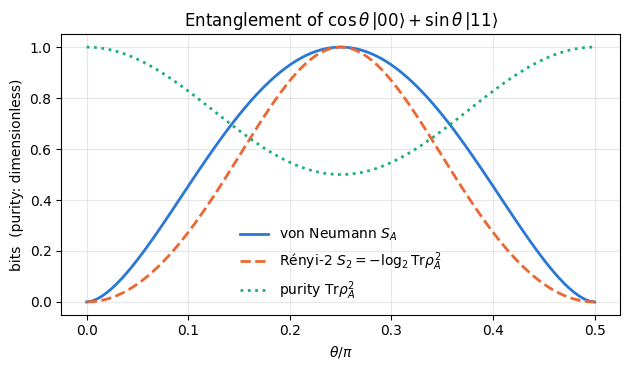

In [32]:
# ==============================================================================
# FIGURE: the two-spin family cos(t)|00> + sin(t)|11> -- entropies and purity versus t
# ==============================================================================
def family_entropies(t):
    psi2 = jnp.array([[jnp.cos(t), 0.0], [0.0, jnp.sin(t)]], dtype=CDTYPE)
    return entanglement_entropy(psi2, (0,)), renyi2_entropy(psi2, (0,)), purity(rdm(psi2, (0,)))

ts = jnp.linspace(0.0, jnp.pi / 2, 101)
S_vn, S_2, gam = jax.vmap(family_entropies)(ts)                     # vmap: one call for the whole parameter sweep

c2 = np.cos(np.asarray(ts)) ** 2
with np.errstate(divide="ignore", invalid="ignore"):
    S_exact = np.nan_to_num(-c2 * np.log2(c2) - (1 - c2) * np.log2(1 - c2))   # binary entropy h(cos^2 t)
print(f"CHECKPOINT S(t) vs binary entropy h(cos^2 t): max error = {np.max(np.abs(np.asarray(S_vn) - S_exact)):.1e}")
assert np.max(np.abs(np.asarray(S_vn) - S_exact)) < 1e3 * TOL

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(ts / np.pi, S_vn, "-", lw=2, label=r"von Neumann $S_A$")
ax.plot(ts / np.pi, S_2, "--", lw=2, label=r"Rényi-2 $S_2=-\log_2{\rm Tr}\rho_A^2$")
ax.plot(ts / np.pi, gam, ":", lw=2, label=r"purity ${\rm Tr}\rho_A^2$")
ax.set_xlabel(r"$\theta/\pi$"); ax.set_ylabel("bits  (purity: dimensionless)")
ax.set_title(r"Entanglement of $\cos\theta\,|00\rangle+\sin\theta\,|11\rangle$"); ax.legend()
fig.tight_layout(); plt.show()

The entropy rises from $0$ (product state $|00\rangle$) to exactly 1 bit at $\theta=\pi/4$ (the Bell state) and falls back to $0$ (product state $|11\rangle$); it equals the binary
entropy $h(\cos^2\theta)$ with $h(x)=-x\log_2x-(1-x)\log_2(1-x)$. The Rényi-2 entropy lies below $S_A$ and touches it where the spectrum is flat ($\theta=0,\pi/4,\pi/2$); the purity
mirrors it, dropping from 1 to $1/2$.

> **JAX practice.** The whole curve was computed by `jax.vmap` over the 101 values of $\theta$: `family_entropies` is written for *one* angle, `vmap` turns it into a batched function
> (including a batched SVD). The clipping `jnp.clip(p, 1e-16)` inside the entropy keeps the end points, where $p=0$ exactly, free of `nan`.

> **Numerical practice — the price of the clip.** Replacing a vanishing $p_k$ by $10^{-16}$ does not give back $0\log_20=0$: each clipped
> value adds $-10^{-16}\log_2 10^{-16}=5.3\cdot10^{-15}$ bit to $S$. The bias is therefore positive and proportional to the number of zero
> Schmidt values. For a GHZ state cut in the middle of $N=12$ spins there are $2^6-2=62$ of them, so $S$ comes out $3.3\cdot10^{-13}$ bit
> above the exact 1 bit — exactly the error the checkpoints of Section 7 report. This is why those asserts use a tolerance of $10^3\,$`TOL`
> instead of `TOL`: the deviation is a known, controlled artefact of the regularisation.

## 7. Entanglement of the zoo as a function of the cut

We now cut an open chain of $N=12$ spins after site $\ell$, $A=\{0,\dots,\ell-1\}$, and plot $S(\ell)$ for every state of the zoo.
Three of the curves can be predicted with pencil and paper, which gives us checkpoints:

* **GHZ**: Eq. (3) is already explicit, $\tfrac1{\sqrt2}|0\dots0\rangle_A|0\dots0\rangle_B+\tfrac1{\sqrt2}|1\dots1\rangle_A|1\dots1\rangle_B$: two Schmidt values $1/\sqrt2$, $S=1$ bit for **every** cut.
* **W**: the excitation is either in $A$ (probability $\ell/N$) or in $B$, and the two alternatives are already orthonormal, so Eq. (3) is
  $|W_N\rangle=\sqrt{\ell/N}\,|W_\ell\rangle|0^{N-\ell}\rangle+\sqrt{1-\ell/N}\,|0^{\ell}\rangle|W_{N-\ell}\rangle$
  (here $|0^m\rangle$ is $m$ spins in $|0\rangle$), giving two Schmidt values and $S(\ell)=h(\ell/N)\le1$ bit.
* **Dicke $D_N^k$**: sort by the number $j$ of excitations in $A$: $|D_N^k\rangle=\sum_j\sqrt{p_j}\,|D_\ell^j\rangle|D_{N-\ell}^{k-j}\rangle$ with the hypergeometric distribution
  $p_j=\binom{\ell}{j}\binom{N-\ell}{k-j}/\binom Nk$; $S$ is its Shannon entropy and grows only like $\tfrac12\log_2N$.
* **Cluster**: with $A$ the *first* $\ell$ spins of an **open** chain the cut severs exactly one $CZ$ bond, and one $CZ$ acting on
  $|{+}\rangle|{+}\rangle$ creates exactly one ebit: $S=1$ bit. The result depends on the shape of $A$ and on the boundary conditions: a block
  *inside* the chain has two boundaries and carries 2 bits, and so does any contiguous block of a periodic ring.

CHECKPOINT W      vs binary entropy h(l/N)      : max error = 3.3e-13
CHECKPOINT Dicke  vs hypergeometric entropy     : max error = 3.1e-13
CHECKPOINT GHZ, cluster vs 1 bit for every cut  : max error = 3.3e-13


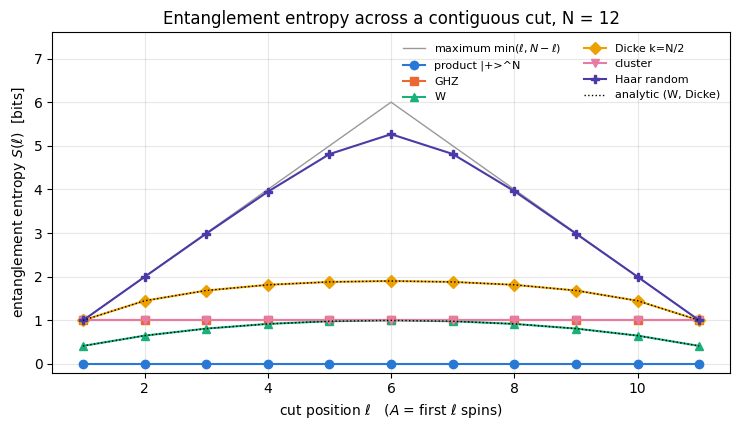

In [33]:
# ==============================================================================
# EXPERIMENT: S(l) for contiguous cuts, N = 12, with analytic checkpoints
# ==============================================================================
N = 12
zoo = make_zoo(N)
cuts = np.arange(1, N)
S_cut = {name: np.array([float(entanglement_entropy(psi, range(l))) for l in cuts]) for name, psi in zoo.items()}


def shannon_bits(p):
    p = np.asarray([x for x in p if x > 0])
    return float(-(p * np.log2(p)).sum())

S_w_exact = np.array([shannon_bits([l / N, 1 - l / N]) for l in cuts])
k = N // 2
S_d_exact = np.array([shannon_bits([comb(l, j) * comb(N - l, k - j) / comb(N, k) for j in range(0, min(l, k) + 1)]) for l in cuts])
print(f"CHECKPOINT W      vs binary entropy h(l/N)      : max error = {np.max(np.abs(S_cut['W'] - S_w_exact)):.1e}")
print(f"CHECKPOINT Dicke  vs hypergeometric entropy     : max error = {np.max(np.abs(S_cut['Dicke k=N/2'] - S_d_exact)):.1e}")
print(f"CHECKPOINT GHZ, cluster vs 1 bit for every cut  : max error = "
      f"{max(np.max(np.abs(S_cut['GHZ'] - 1)), np.max(np.abs(S_cut['cluster'] - 1))):.1e}")
assert np.max(np.abs(S_cut["W"] - S_w_exact)) < 1e3 * TOL and np.max(np.abs(S_cut["Dicke k=N/2"] - S_d_exact)) < 1e3 * TOL
assert np.max(np.abs(S_cut["GHZ"] - 1)) < 1e3 * TOL and np.max(np.abs(S_cut["cluster"] - 1)) < 1e3 * TOL

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(cuts, np.minimum(cuts, N - cuts), color="0.6", lw=1, ls="-", label=r"maximum $\min(\ell,N-\ell)$")
for name in ZOO_NAMES:
    ax.plot(cuts, S_cut[name], ls="-", lw=1.5, ms=6, label=name, **ZOO_STYLE[name])
ax.plot(cuts, S_w_exact, "k:", lw=1); ax.plot(cuts, S_d_exact, "k:", lw=1, label="analytic (W, Dicke)")
ax.set_xlabel(r"cut position $\ell$   ($A$ = first $\ell$ spins)"); ax.set_ylabel(r"entanglement entropy $S(\ell)$  [bits]")
ax.set_title(f"Entanglement entropy across a contiguous cut, N = {N}")
ax.legend(loc="upper right", fontsize=8, ncol=2); ax.set_ylim(-0.2, N / 2 + 1.6)
fig.tight_layout(); plt.show()

**Reading the figure.** The grey line is the absolute maximum $\min(\ell,N-\ell)$. The "famous" entangled states are, by this measure, *weakly* entangled: GHZ and cluster carry
exactly 1 bit across any cut (their markers coincide), W at most 1 bit, the Dicke state about 1.9 bits at the centre. Only the random state comes close to the
maximum, with a characteristic triangular shape. All the analytic predictions are met to $3\cdot10^{-13}$ bit, the bias of the $0\log 0$
clip counted in the practice box of Section 6.3.

**Non-contiguous cuts.** Entropy depends on *which* spins form $A$. For the partition "even sites | odd sites" every bond of the chain is cut:

In [34]:
# ==============================================================================
# Same states, a different bipartition: even sites vs odd sites  (N = 12, |A| = 6)
# ==============================================================================
A_half, A_even = tuple(range(N // 2)), tuple(range(0, N, 2))
print(f"{'state':16s} {'S(first half)':>14s} {'S(even sites)':>14s} {'S2(even sites)':>15s}")
for name, psi in zoo.items():
    print(f"{name:16s} {float(entanglement_entropy(psi, A_half)):14.4f} {float(entanglement_entropy(psi, A_even)):14.4f}"
          f" {float(renyi2_entropy(psi, A_even)):15.4f}")

# local unitaries do not change entanglement: GHZ written in the X basis (H on every spin)
ghz_x = zoo["GHZ"]
for q in range(N):
    ghz_x = apply_gate(ghz_x, H, [q])
print(f"\nGHZ in the X basis: {int(jnp.sum(jnp.abs(ghz_x) > 1e-12))} non-zero amplitudes (instead of 2), "
      f"S(first half) = {float(entanglement_entropy(ghz_x, A_half)):.6f} bits (unchanged)")
assert abs(float(entanglement_entropy(ghz_x, A_half)) - 1) < 1e3 * TOL

state             S(first half)  S(even sites)  S2(even sites)
product |+>^N            0.0000         0.0000          0.0000
GHZ                      1.0000         1.0000          1.0000
W                        1.0000         1.0000          1.0000
Dicke k=N/2              1.9016         1.9016          1.6942
cluster                  1.0000         6.0000          6.0000
Haar random              5.2662         5.2773          4.9956



GHZ in the X basis: 2048 non-zero amplitudes (instead of 2), S(first half) = 1.000000 bits (unchanged)


* The **cluster state** jumps from 1 bit to $N/2=6$ bits — the *maximum* possible for six spins. The even/odd partition cuts all 11 bonds and each spin of $A$ ends up maximally entangled with its neighbours in $B$.
  The cluster state has short-range entanglement: $S$ grows with the number of bonds that cross the boundary of $A$, saturating at $\min(|A|,|B|)$. This is the prototype of an **area law**.
* **GHZ** stays at 1 bit for *every* bipartition: a single, global, shared bit.
* W, Dicke and the random state barely change: they are permutation symmetric (or structureless), so only the *size* of $A$ matters.
* Rewriting GHZ in the $X$ basis spreads it over $2^{N-1}=2048$ basis states, but the entropy is unchanged — entanglement is invariant under local basis changes, unlike the participation number of Section 2.6.

## 8. Random states and the Page value

The random state in the last figure almost saturated the bound. How entangled is a typical state *on average*? Page (1993) conjectured, and Foong and Kanno (1994) proved, a closed formula for the mean entanglement entropy
of Haar-random states in a Hilbert space of dimensions $d_A\le d_B$ (quoted without proof; in nats):

$$\langle S_A\rangle=\sum_{k=d_B+1}^{d_Ad_B}\frac1k-\frac{d_A-1}{2d_B}\;\;\approx\;\;\ln d_A-\frac{d_A}{2d_B}\quad(d_A,d_B\gg1).$$

In bits, for $|A|=\ell\le N/2$ spins: $\langle S\rangle\approx\ell-2^{\ell-(N-\ell)}/(2\ln2)$. A random state is **almost maximally entangled**: for small subsystems the deficit is exponentially small,
and for the half-chain it is a constant $1/(2\ln2)\approx0.72$ bit, *independent of $N$*. Entropy proportional to the number of spins in $A$ is called a **volume law**.

We test the formula by brute force: `vmap` over a batch of PRNG keys generates all the states in one compiled call, and a second `vmap` computes their entropies. The spread over samples gives the statistical error of the mean,
$\sigma/\sqrt{M}$ for $M$ samples.

 l     mean S   std.err.  Page exact  deviation/std.err.  sample std
 1    0.99777    0.00009     0.99789               -1.28     0.00182
 2    1.98907    0.00020     1.98944               -1.82     0.00402
 3    2.95559    0.00040     2.95563               -0.09     0.00806
 4    3.82026    0.00072     3.82040               -0.18     0.01444
 5    4.27904    0.00113     4.27947               -0.39     0.02259
 6    3.81982    0.00073     3.82040               -0.79     0.01452
 7    2.95531    0.00039     2.95563               -0.81     0.00774
 8    1.98950    0.00018     1.98944                0.37     0.00362
 9    0.99781    0.00009     0.99789               -0.85     0.00177


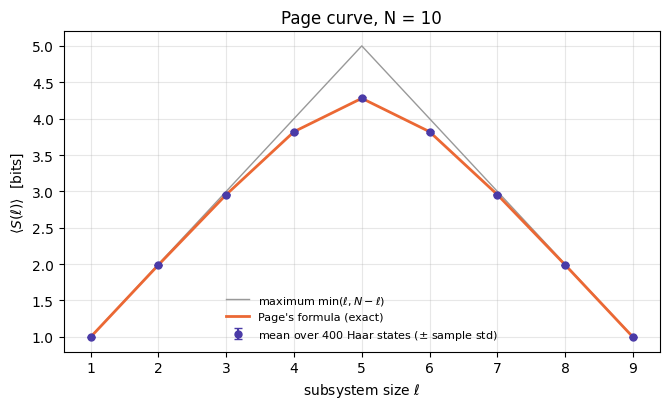

half-chain deficit  N/2 - <S> = 0.7210 bits    (large-N prediction 1/(2 ln 2) = 0.7213)


In [35]:
# ==============================================================================
# EXPERIMENT: Page curve from M random states, N = 10
# ==============================================================================
N, M_SAMPLES = 10, 400
keys = jax.random.split(jax.random.PRNGKey(1), M_SAMPLES)


def page_value_bits(dA, dB):
    """Exact mean entanglement entropy of a Haar-random state (Page's formula), in bits."""
    dA, dB = min(dA, dB), max(dA, dB)
    nats = sum(1.0 / k for k in range(dB + 1, dA * dB + 1)) - (dA - 1) / (2 * dB)
    return nats / np.log(2)


cuts = np.arange(1, N)
states = jax.jit(jax.vmap(partial(haar_state, N=N)))(keys)          # all M random states at once: shape (M, 2, ..., 2)
mean, sem, std = [], [], []
for l in cuts:
    # jit(vmap(...)): ONE compiled program performs the M reshapes + SVDs for this cut (the cut is static)
    batch = jax.jit(jax.vmap(partial(entanglement_entropy, subsystem=tuple(range(l)))))
    S = np.asarray(batch(states))
    mean.append(S.mean()); std.append(S.std(ddof=1)); sem.append(S.std(ddof=1) / np.sqrt(M_SAMPLES))
mean, sem, std = map(np.array, (mean, sem, std))
page = np.array([page_value_bits(2 ** l, 2 ** (N - l)) for l in cuts])

print(f"{'l':>2s} {'mean S':>10s} {'std.err.':>10s} {'Page exact':>11s} {'deviation/std.err.':>19s} {'sample std':>11s}")
for l, m_, e_, p_, s_ in zip(cuts, mean, sem, page, std):
    print(f"{l:2d} {m_:10.5f} {e_:10.5f} {p_:11.5f} {(m_ - p_) / e_:19.2f} {s_:11.5f}")
assert np.all(np.abs(mean - page) < 4 * sem), "sample mean deviates from Page's formula by more than 4 standard errors"

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(cuts, np.minimum(cuts, N - cuts), color="0.6", lw=1, label=r"maximum $\min(\ell,N-\ell)$")
ax.plot(cuts, page, "-", color=PALETTE[1], lw=2, label="Page's formula (exact)")
ax.errorbar(cuts, mean, yerr=std, fmt="o", color=PALETTE[5], ms=5, capsize=3,
            label=f"mean over {M_SAMPLES} Haar states ($\\pm$ sample std)")
ax.set_xlabel(r"subsystem size $\ell$"); ax.set_ylabel(r"$\langle S(\ell)\rangle$  [bits]")
ax.set_title(f"Page curve, N = {N}"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()
print(f"half-chain deficit  N/2 - <S> = {N / 2 - mean[N // 2 - 1]:.4f} bits    (large-N prediction 1/(2 ln 2) = {1 / (2 * np.log(2)):.4f})")

The sample means agree with Page's formula within the statistical error for every cut (at most $1.8$ standard errors; the `assert` allows four).
All nine cuts are evaluated on the same 400 states, so the nine deviations are correlated, which is why most of them share one sign. Two more lessons hide in the table:

* The **sample standard deviation is tiny** (the error bars in the plot are smaller than the markers): *every single* random state has almost exactly the Page entropy. This "typicality" is a
  concentration-of-measure effect of high-dimensional spaces; it is the reason why a single random state is a fair representative of the whole ensemble.
* The half-chain deficit is already within about $10^{-3}$ bit of the asymptotic constant $1/(2\ln2)$ at $N=10$.

> **Physics insight.** A subsystem of a random pure state is, to exponential accuracy, *maximally mixed*: no measurement on the subsystem alone can tell it apart from $\mathbb 1/2^{\ell}$, although the global state is pure.
> All the information sits in the correlations between the subsystem and the rest. In a companion paper Page used this result to follow the information carried by Hawking radiation (Page 1993, *Information in black hole radiation*).

## 9. Area law versus volume law: ground states are special

Random states are the overwhelming majority of the Hilbert space, but they are not the lowest-energy states of physical Hamiltonians. **Ground states of local Hamiltonians are extremely atypical.**
For a gapped one-dimensional Hamiltonian with short-range interactions, Hastings proved (2007) that the entanglement entropy of a block is bounded by a constant independent of its length —
the **area law** (in 1D the "area" of the boundary of a block is just a point or two). At a quantum critical point the gap closes and the entropy grows logarithmically, as found for critical spin chains by Vidal, Latorre, Rico and Kitaev (2003); conformal field theory (Calabrese and Cardy, 2004) gives the form of this mild violation; for an open chain

$$S(\ell)=\frac c6\,\ln\!\Big[\frac{2N}{\pi}\sin\frac{\pi\ell}{N}\Big]+\text{const}\qquad\text{(nats)},$$

with the *central charge* $c$ (both results quoted without proof). The argument of the logarithm is the **chord length** of the cut on a
circle of circumference $2N$; it replaces $\ell$ so that the formula respects the symmetry $\ell\to N-\ell$ of a finite chain. The
prefactor counts the boundaries of $A$: a block at the end of an **open** chain has one, and gets $c/6$; a block of a **periodic** ring has
two, and the formula becomes $S(\ell)=\tfrac c3\ln[(N/\pi)\sin(\pi\ell/N)]+\text{const}$. Our chains below are open (the default of
`heisenberg_terms`) and $A$ is always the first $\ell$ spins, so $c/6$ is the right prefactor; using $c/3$ by mistake halves the fitted $c$.
Compare all of this with the volume law $S\approx\ell$ of random states.

We test this on the transverse-field Ising chain of [notebook 03](../ch02_spin_systems_textbook_way/03_quantum_many_body_spin_systems.ipynb),

$$H=-J\sum_{i}Z_iZ_{i+1}-h\sum_iX_i,\qquad J=1,$$

in the gapped paramagnetic phase ($h=1.5$) and at the critical point ($h=1$, where $c=1/2$). The ground state comes from the **Lanczos method**, a matrix-free eigensolver that
needs nothing but the action $H|\psi\rangle$ (sum of local `apply_gate` contractions, notebook 05); it is derived in detail in
[notebook 11 (Chapter 5)](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb). Here we use the engine version as a black box and check it: we compare the energy
against dense diagonalisation for a small chain, and for every $N$ we monitor the residual $\|H\psi-E\psi\|$, which vanishes only for a true eigenstate.

In [36]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


In [37]:
# ==============================================================================
# PARAMETERS of the ground-state experiment
# ==============================================================================
J_ISING = 1.0                       # ferromagnetic coupling  -J Z_i Z_{i+1}
FIELDS = {"gapped  (h = 1.5)": 1.5, "critical (h = 1.0)": 1.0}     # transverse fields  -h X_i
N_LIST = [6, 8, 10, 12, 14]         # chain lengths for the scaling plot
N_MAX = N_LIST[-1]
LANCZOS_M, LANCZOS_RESTARTS = 60, 2  # Krylov dimension and number of restarts


def tfim_terms(N, h):
    """H = -J sum Z Z - h sum X as a list of local terms (open chain)."""
    return heisenberg_terms(N, Jxx=0.0, Jyy=0.0, Jzz=-J_ISING, hx=-h)


# --- CHECKPOINT: Lanczos vs dense diagonalisation at N = 8 -------------------------------------------
for label, h in FIELDS.items():
    terms = tfim_terms(8, h)
    E_lanczos, psi0 = lanczos_ground_state(terms, 8, m=LANCZOS_M, restarts=LANCZOS_RESTARTS)
    E_dense = float(jnp.linalg.eigvalsh(dense_hamiltonian(terms, 8))[0])
    print(f"CHECKPOINT N=8 {label}: E0(Lanczos) = {E_lanczos:.10f}, E0(dense) = {E_dense:.10f}, diff = {abs(E_lanczos - E_dense):.1e}")
    assert abs(E_lanczos - E_dense) < 1e4 * TOL

CHECKPOINT N=8 gapped  (h = 1.5): E0(Lanczos) = -13.1914049522, E0(dense) = -13.1914049522, diff = 5.3e-15


CHECKPOINT N=8 critical (h = 1.0): E0(Lanczos) = -9.8379514475, E0(dense) = -9.8379514475, diff = 0.0e+00


In [38]:
# ==============================================================================
# EXPERIMENT: ground states for all N, entropy profiles, Schmidt spectra
# ==============================================================================
t0 = time.perf_counter()
ground = {}                                                       # (label, N) -> state tensor
for label, h in FIELDS.items():
    for n in N_LIST:
        terms = tfim_terms(n, h)
        E0, psi0 = lanczos_ground_state(terms, n, m=LANCZOS_M, restarts=LANCZOS_RESTARTS)
        residual = float(jnp.linalg.norm(apply_hamiltonian(terms, psi0) - E0 * psi0))
        assert residual < 1e4 * TOL, f"Lanczos not converged: residual {residual:.1e}"
        ground[(label, n)] = psi0
        print(f"{label}  N = {n:2d}:  E0/N = {E0 / n:+.6f}   residual |H psi - E psi| = {residual:.1e}")
random_states = {n: haar_state(jax.random.PRNGKey(100 + n), n) for n in N_LIST}
print(f"\nall ground states computed in {time.perf_counter() - t0:.1f} s")

gapped  (h = 1.5)  N =  6:  E0/N = -1.641262   residual |H psi - E psi| = 1.1e-14


gapped  (h = 1.5)  N =  8:  E0/N = -1.648926   residual |H psi - E psi| = 1.1e-14


gapped  (h = 1.5)  N = 10:  E0/N = -1.653525   residual |H psi - E psi| = 3.7e-15


gapped  (h = 1.5)  N = 12:  E0/N = -1.656592   residual |H psi - E psi| = 9.2e-15


gapped  (h = 1.5)  N = 14:  E0/N = -1.658783   residual |H psi - E psi| = 1.1e-13


critical (h = 1.0)  N =  6:  E0/N = -1.216038   residual |H psi - E psi| = 9.4e-15


critical (h = 1.0)  N =  8:  E0/N = -1.229744   residual |H psi - E psi| = 1.4e-14


critical (h = 1.0)  N = 10:  E0/N = -1.238149   residual |H psi - E psi| = 3.4e-15


critical (h = 1.0)  N = 12:  E0/N = -1.243831   residual |H psi - E psi| = 1.7e-14


critical (h = 1.0)  N = 14:  E0/N = -1.247929   residual |H psi - E psi| = 1.2e-12

all ground states computed in 33.3 s


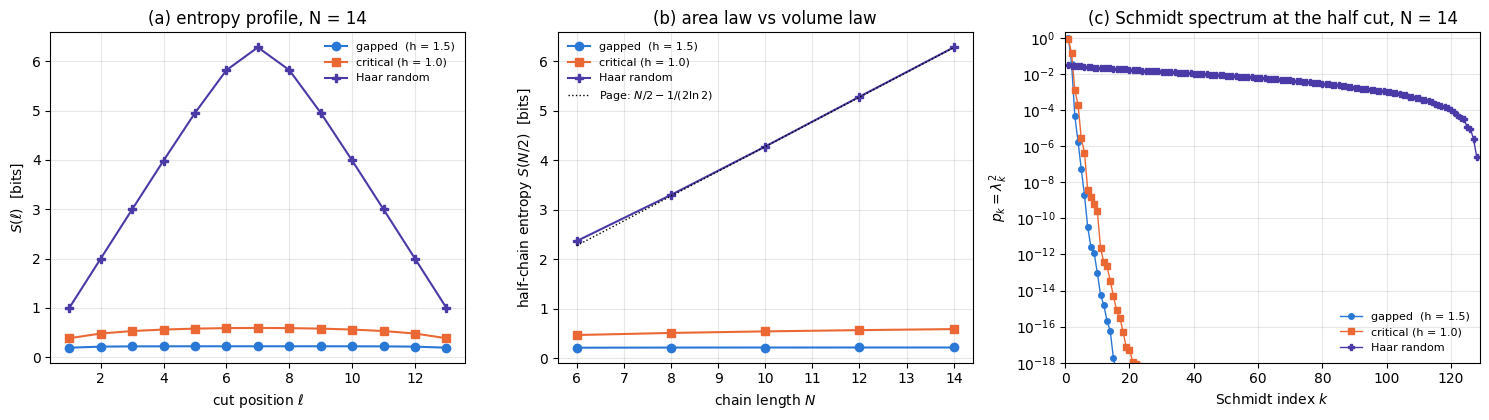

gapped  (h = 1.5): S(N/2) for N = [6, 8, 10, 12, 14]: [0.2171 0.22   0.2209 0.2213 0.2214]
critical (h = 1.0): S(N/2) for N = [6, 8, 10, 12, 14]: [0.4732 0.5153 0.5469 0.5721 0.593 ]
Haar random       : S(N/2) for N = [6, 8, 10, 12, 14]: [2.3704 3.3022 4.2803 5.2863 6.2834]

central charge fitted from the critical profile (N = 14, cuts 2..N-2): c = 0.562   (exact: 1/2)

how many Schmidt states are needed so that the discarded weight sum_{k>chi} p_k < 1e-8 ?   (out of 2^(N/2) = 128)
   gapped  (h = 1.5)    chi = 5
   critical (h = 1.0)   chi = 6
   Haar random          chi = 128


In [39]:
# ==============================================================================
# FIGURE: (a) S(l) at N = 14, (b) half-chain entropy vs N, (c) Schmidt spectrum at the half cut
# ==============================================================================
cuts = np.arange(1, N_MAX)
styles = {"gapped  (h = 1.5)": dict(color=PALETTE[0], marker="o"), "critical (h = 1.0)": dict(color=PALETTE[1], marker="s"),
          "Haar random": dict(color=PALETTE[5], marker="P")}
profiles = {label: np.array([float(entanglement_entropy(ground[(label, N_MAX)], range(l))) for l in cuts]) for label in FIELDS}
profiles["Haar random"] = np.array([float(entanglement_entropy(random_states[N_MAX], range(l))) for l in cuts])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
ax = axes[0]
for label, S in profiles.items():
    ax.plot(cuts, S, ls="-", lw=1.5, label=label, **styles[label])
ax.set_xlabel(r"cut position $\ell$"); ax.set_ylabel(r"$S(\ell)$  [bits]"); ax.set_title(f"(a) entropy profile, N = {N_MAX}"); ax.legend(fontsize=8)

ax = axes[1]
half = {label: [float(entanglement_entropy(ground[(label, n)], range(n // 2))) for n in N_LIST] for label in FIELDS}
half["Haar random"] = [float(entanglement_entropy(random_states[n], range(n // 2))) for n in N_LIST]
for label, S in half.items():
    ax.plot(N_LIST, S, ls="-", lw=1.5, label=label, **styles[label])
ax.plot(N_LIST, [n / 2 - 1 / (2 * np.log(2)) for n in N_LIST], "k:", lw=1, label=r"Page: $N/2-1/(2\ln 2)$")
ax.set_xlabel("chain length $N$"); ax.set_ylabel(r"half-chain entropy $S(N/2)$  [bits]"); ax.set_title("(b) area law vs volume law"); ax.legend(fontsize=8)

ax = axes[2]
spectra = {label: np.asarray(schmidt_values(ground[(label, N_MAX)], range(N_MAX // 2))) ** 2 for label in FIELDS}
spectra["Haar random"] = np.asarray(schmidt_values(random_states[N_MAX], range(N_MAX // 2))) ** 2
for label, p in spectra.items():
    ax.semilogy(np.arange(1, len(p) + 1), np.clip(p, 1e-20, None), ls="-", lw=1, ms=4, label=label, **styles[label])
ax.set_ylim(1e-18, 2); ax.set_xlim(0, 2 ** (N_MAX // 2) + 1)
ax.set_xlabel("Schmidt index $k$"); ax.set_ylabel(r"$p_k=\lambda_k^2$"); ax.set_title(f"(c) Schmidt spectrum at the half cut, N = {N_MAX}"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

# --- numbers quoted in the text --------------------------------------------------------------------
for label in FIELDS:
    print(f"{label}: S(N/2) for N = {N_LIST}: {np.round(half[label], 4)}")
print(f"Haar random       : S(N/2) for N = {N_LIST}: {np.round(half['Haar random'], 4)}")

# central charge from the critical profile:  S[nats] = (c/6) ln[(2N/pi) sin(pi l/N)] + const
x = np.log(2 * N_MAX / np.pi * np.sin(np.pi * cuts / N_MAX)) / 6.0
c_fit = np.polyfit(x[1:-1], profiles["critical (h = 1.0)"][1:-1] * np.log(2), 1)[0]   # biased upward at N = 14 (see the text)
print(f"\ncentral charge fitted from the critical profile (N = {N_MAX}, cuts 2..N-2): c = {c_fit:.3f}   (exact: 1/2)")
assert 0.4 < c_fit < 0.7

print("\nhow many Schmidt states are needed so that the discarded weight sum_{k>chi} p_k < 1e-8 ?   (out of 2^(N/2) = "
      f"{2 ** (N_MAX // 2)})")
for label, p in spectra.items():
    tail = np.cumsum(p[::-1])[::-1]                               # tail[k] = sum_{j>=k} p_j
    chi = int(np.argmax(tail < 1e-8)) if np.any(tail < 1e-8) else len(p)
    print(f"   {label:20s} chi = {chi}")

**(a)** At $N=14$ the gapped ground state has a flat entropy profile of about $0.22$ bit: once the cut is more than a correlation length away from the ends, moving it changes nothing — all entanglement
sits *at the cut*. The critical ground state has a gentle dome of about $0.6$ bit. The random state rises with slope 1 bit per spin up to the centre.

**(b)** This is the area-law/volume-law dichotomy in one picture. Going from 6 to 14 spins changes the half-chain entropy of the gapped ground state only in the third decimal place ($0.2171\to0.2214$ bit)
(it has converged to a constant); at criticality it creeps up logarithmically; for random states it grows linearly, following Page's $N/2-0.72$. The fit of the critical profile to the conformal formula
gives $c=0.56$, about 12 % above the exact $c=1/2$.

That 12 % is a systematic **bias**: the Calabrese–Cardy formula is the leading term of a large-$N$ expansion, and the subleading corrections
— the non-universal boundary constant, the finite-size corrections to it, and an oscillating term that alternates with the parity of $\ell$
in the open Ising chain — are all absorbed into the fitted slope. The bias is positive and shrinks only logarithmically: solving the same
model exactly by free fermions and fitting in exactly the same way gives $c=0.562$ at $N=14$, $0.554$ at $N=20$, $0.544$ at $N=32$, $0.532$ at
$N=64$, $0.522$ at $N=128$ and still $0.515$ at $N=256$. A 14-spin fit that lands within 15 % of $1/2$ is therefore what the method *should*
deliver; a fit that landed on $0.500$ would be a coincidence. Quoting a central charge from short chains without such an extrapolation — or
without fitting the subleading terms as well — is the standard way to overstate it.

**(c)** The Schmidt spectrum explains why this matters for *numerics*. In the ground states $p_k$ falls off roughly exponentially: only a handful of Schmidt states carry weight above $10^{-8}$
— out of 128. The random state is the opposite: most of its 128 values lie within two decades of the largest, only the last few drop
steeply, and the discarded weight stays above $10^{-8}$ until every one of the 128 is kept. Keeping only the $\chi$ largest terms of Eq. (3) at *every* cut is exactly what a **matrix product state** does; the
discarded weight $\sum_{k>\chi}p_k$ is its truncation error. Area law $\Rightarrow$ small $\chi$ suffices $\Rightarrow$ memory $O(N\chi^2)$ instead of $O(2^N)$: this is why DMRG and MPS-TEBD
([notebook 18 (Chapter 7)](../ch07_tensor_networks/18_mps_tebd.ipynb)) reach hundreds of spins for ground states, and why they fail for volume-law states (e.g. long after a quench).

> **Common pitfall.** In the ferromagnetic phase $h<J$ of the finite chain the two lowest states (the "cat" combinations of all-up and all-down) are split only by an exponentially small gap $\sim h^N$.
> An iterative eigensolver then returns an arbitrary superposition from this doublet, and the entropy you measure can be anything between the symmetry-broken value and that plus 1 bit. Always check what your solver converged to (Exercise 6).

## 10. A first phase diagram: the XXZ chain in a transverse field

### 10.1 The model

The tools of this notebook are now used for a small research-style study: map the ground-state phases of a chain by scanning two
parameters and watching a few observables. The model is the **XXZ chain in a transverse field** (Pauli convention, $J=1$, open chain),

$$ H(\Delta,h_x)=J\sum_{i=0}^{N-2}\big(X_iX_{i+1}+Y_iY_{i+1}+\Delta\,Z_iZ_{i+1}\big)+h_x\sum_{i=0}^{N-1}X_i . \tag{7}$$

**Without the field** ($h_x=0$) it is one of the few interacting many-body models with an exact solution. With the field the exact solution
is lost, and which properties survive is decided by the symmetries (Section 10.3). First we see where the exact solution comes from.

### 10.2 The chain without field: magnons and the Bethe ansatz

Take a **ring** of $N$ sites at $h_x=0$ and start from the state with all spins up, $|0\cdots0\rangle$. Two rules give the action of one bond
term on two neighbouring spins. With $X|0\rangle=|1\rangle$, $Y|0\rangle=i|1\rangle$ and $Y|1\rangle=-i|0\rangle$,

$$ (XX+YY)|00\rangle=|11\rangle+i^2|11\rangle=0,\qquad (XX+YY)|01\rangle=|10\rangle+(i)(-i)|10\rangle=2|10\rangle , \tag{8}$$

so the exchange term moves a flipped spin to the neighbouring site with amplitude $2$ and does nothing to two parallel spins, while $ZZ$ gives
$+1$ for parallel and $-1$ for antiparallel spins. The reference state has the energy $E_{\rm ref}=\Delta N$.

**One magnon.** Let $|n\rangle$ be the state with only spin $n$ flipped. Its two bonds become antiparallel (each lowers the diagonal energy by
$2\Delta$), and the exchange moves the flipped spin to either neighbour:
$H|n\rangle=(\Delta N-4\Delta)|n\rangle+2|n-1\rangle+2|n+1\rangle$. The ring is translation invariant, so we insert the plane wave
$|k\rangle=\sum_ne^{ikn}|n\rangle$ and shift the summation index in the two hopping terms:

$$ H|k\rangle=\big(\Delta N-4\Delta+2e^{ik}+2e^{-ik}\big)|k\rangle=\big(E_{\rm ref}+\varepsilon(k)\big)|k\rangle,\qquad
   \varepsilon(k)=4(\cos k-\Delta),\qquad k=\frac{2\pi m}{N} . \tag{9}$$

The flipped spin travels as a quasi-particle, a **magnon**. The cheapest one has $k=\pi$ and costs $4(-1-\Delta)$. For $\Delta<-1$ every magnon
costs energy: the polarised state is the ground state, with a gap $4(|\Delta|-1)$ on the ring. For $\Delta>-1$ magnons near $k=\pi$ have negative
energy, the polarised state is unstable, and the ground state contains a finite density of *interacting* magnons.

**Two magnons.** Let $a(n_1,n_2)$, $n_1<n_2$, be the amplitude of the state with these two spins flipped. Bethe's ansatz is a superposition of
two plane waves with exchanged momenta, $a(n_1,n_2)=A_{12}e^{i(k_1n_1+k_2n_2)}+A_{21}e^{i(k_2n_1+k_1n_2)}$. When the magnons are apart it is an
eigenstate with energy $E_{\rm ref}+\varepsilon(k_1)+\varepsilon(k_2)$ for any $A_{12},A_{21}$. When they are neighbours only two bonds are
antiparallel and each magnon can hop only outwards, $E\,a(n,n+1)=(\Delta N-4\Delta)a(n,n+1)+2a(n-1,n+1)+2a(n,n+2)$; the equation for separated
magnons, applied formally at $n_2=n_1+1$, would instead contain $(\Delta N-8\Delta)$ and the two extra terms $2a(n+1,n+1)+2a(n,n)$. Subtracting the
two equations, the ansatz solves the true problem if

$$ a(n,n)+a(n+1,n+1)-2\Delta\,a(n,n+1)=0
   \quad\Longrightarrow\quad
   \frac{A_{21}}{A_{12}}=-\frac{1+e^{i(k_1+k_2)}-2\Delta e^{ik_2}}{1+e^{i(k_1+k_2)}-2\Delta e^{ik_1}} , \tag{10}$$

a pure phase for real momenta: the scattering phase of two magnons. Periodicity, $a(n_1,n_2)=a(n_2,n_1+N)$, requires $e^{ik_1N}=A_{12}/A_{21}$.
Bethe's insight (1931) was that with $M$ magnons every collision factorises into such two-body scatterings, which gives $M$ coupled
**Bethe equations** (quoted for general $M$; for $M=2$ they are the condition just derived)

$$ e^{ik_jN}=\prod_{l\neq j}\Big(-\frac{1+e^{i(k_j+k_l)}-2\Delta e^{ik_j}}{1+e^{i(k_j+k_l)}-2\Delta e^{ik_l}}\Big),\qquad j=1,\dots,M . \tag{11}$$

Their solutions give the exact spectrum. Bethe solved $\Delta=1$; Yang and Yang (1966) proved the ansatz for the ground state and analysed all
$\Delta$. The ground-state phases in the thermodynamic limit are (quoted; see Takahashi 1999 and Giamarchi 2003):

| anisotropy | phase | ground state |
|---|---|---|
| $\Delta<-1$ | ferromagnet (Ising-like along $z$) | all spins up or all down; gapped |
| $-1<\Delta\le1$ | critical ("XY phase", a Luttinger liquid) | no long-range order; gapless; power-law correlations |
| $\Delta>1$ | Néel antiferromagnet along $z$ | alternating $\uparrow\downarrow\uparrow\downarrow$ order; gapped, but the gap opens exponentially slowly above $\Delta=1$ |

The cell below checks Eq. (9): the eigenvalues of $H$ restricted to the $N$ states with one flipped spin must be $E_{\rm ref}+\varepsilon(2\pi m/N)$.

In [40]:
# ==============================================================================
# CHECKPOINT: one-magnon spectrum of the ring, Eq. (9)
# ==============================================================================
N_RING = 8
one_flip = [2 ** (N_RING - 1 - n) for n in range(N_RING)]          # flat indices of the states |n> (spin n flipped)
for Delta_ring in (0.5, -2.0):
    H_ring = jnp.real(dense_hamiltonian(heisenberg_terms(N_RING, Jxx=1.0, Jyy=1.0, Jzz=Delta_ring, periodic=True), N_RING))
    w_sector = np.sort(np.linalg.eigvalsh(np.asarray(H_ring)[np.ix_(one_flip, one_flip)]))
    k_ring = 2 * np.pi * np.arange(N_RING) / N_RING
    w_magnon = np.sort(Delta_ring * N_RING + 4 * (np.cos(k_ring) - Delta_ring))
    err = np.max(np.abs(w_sector - w_magnon))
    print(f"CHECKPOINT ring N={N_RING}, Delta={Delta_ring:+.1f}: one-magnon sector vs Delta N + 4(cos k - Delta): max |diff| = {err:.1e}")
    assert err < 1e3 * TOL

CHECKPOINT ring N=8, Delta=+0.5: one-magnon sector vs Delta N + 4(cos k - Delta): max |diff| = 3.6e-15
CHECKPOINT ring N=8, Delta=-2.0: one-magnon sector vs Delta N + 4(cos k - Delta): max |diff| = 4.0e-15


### 10.3 Symmetries, and which of them the field breaks

A symmetry is a unitary $U$ with $UHU^\dagger=H$. For single-spin rotations it is enough to check how each Pauli product in Eq. (7) transforms.

| symmetry | operator | why $H(\Delta,0)$ has it | with $h_x\neq0$ |
|---|---|---|---|
| rotations about $z$, $U(1)$ | $e^{-i\varphi M_z/2}$, $M_z=\sum_iZ_i$ | $X_iX_j+Y_iY_j$ is invariant under a common rotation in the $xy$ plane, $Z_iZ_j$ trivially | **broken**: $X_i$ rotates into $Y_i$; $M_z$ is no longer conserved |
| $\pi$ rotation about $z$ (an element of the $U(1)$) | $\prod_iZ_i$: $X\to-X$, $Y\to-Y$ | products of two equal Paulis are invariant | **broken**: the field term changes sign |
| spin flip, $\pi$ rotation about $x$ | $P=\prod_iX_i$: $Y\to-Y$, $Z\to-Z$ | products of two equal Paulis are invariant | **preserved**: the only internal symmetry left |
| full $SU(2)$, only at $\Delta=1$ | all components of the total spin | $X_iX_j+Y_iY_j+Z_iZ_j=2\,\mathrm{SWAP}_{ij}-1$ is rotation invariant | $\Delta\neq1$ reduces it to $U(1)\rtimes\mathbb Z_2$, the field to $\mathbb Z_2$ |
| time reversal | $\Theta=\big(\prod_i iY_i\big)K$, flips every spin | the exchange terms are even in the spins | **broken**: a magnetic field is odd under time reversal |
| reflection $i\to N-1-i$ | spatial | uniform couplings | preserved (the field is uniform) |

A related transformation, which is not a symmetry, provides a useful map: the rotation $U_{\rm sub}=\prod_{i\ \rm odd}Z_i$ of every second spin
changes the sign of $X_iX_{i+1}+Y_iY_{i+1}$ on every bond and leaves $Z_iZ_{i+1}$ unchanged, so at $h_x=0$ it maps $H(\Delta)$ onto
$-\sum(X_iX_{i+1}+Y_iY_{i+1})+\Delta\sum Z_iZ_{i+1}$. At $\Delta=-1$ the result is $-\sum(X_iX_{i+1}+Y_iY_{i+1}+Z_iZ_{i+1})$, the $SU(2)$
**ferromagnet**: its ground state is a multiplet of $N+1$ degenerate states, and the point $\Delta=-1$, $h_x=0$ is special. With a field the
same rotation turns the uniform field into a staggered one, so the phase diagram is not symmetric under $\Delta\to-\Delta$.

**Symmetries and order.** The ferromagnet spontaneously breaks the spin flip $P$ (all up versus all down); the Néel state breaks $P$ and the
translation by one site. In the critical phase nothing is broken: a *continuous* symmetry like $U(1)$ is not broken spontaneously in the
ground state of a one-dimensional quantum chain (the field-theory statement in 1+1 dimensions is Coleman's theorem, Coleman 1973; the ferromagnet,
whose order parameter commutes with $H$, is the exception), and its place is taken by power-law correlations ("quasi-long-range order"). Once the field has removed the
$U(1)$, only the $\mathbb Z_2$ symmetry $P$ remains, and it can be broken; the literature finds that the field opens a gap in the critical
phase and induces antiferromagnetic order along $y$, the direction perpendicular to both the anisotropy axis and the field
(Dmitriev, Krivnov and Ovchinnikov 2002). We test this below.

**Order in a finite chain is read from correlations.** A finite chain has no spontaneous symmetry breaking: its ground state in a symmetry
sector is symmetric, so $\langle Z_i\rangle=\langle Y_i\rangle=0$ exactly, even deep in an ordered phase (the ferromagnetic ground state is the
cat $(|{\uparrow\cdots\uparrow}\rangle+|{\downarrow\cdots\downarrow}\rangle)/\sqrt2$). The order shows up in the correlations between distant
spins, which do not vanish: $\langle Z_iZ_j\rangle\to m^2$ in the ferromagnet and $(-1)^{i-j}\langle Z_iZ_j\rangle\to m_{\rm st}^2$ in a Néel state.
We therefore measure, between the bulk spins $2$ and $7$ at the odd distance $r=5$,

$$ C^{zz}=\langle Z_2Z_7\rangle,\qquad C^{yy}_{\rm st}=(-1)^r\langle Y_2Y_7\rangle=-\langle Y_2Y_7\rangle . \tag{12}$$

Because $r$ is odd, $C^{zz}$ is positive for ferromagnetic and negative for Néel correlations along $z$; $C^{yy}_{\rm st}$ is positive for
antiferromagnetic correlations along $y$. A second, independent indicator of a broken $\mathbb Z_2$ symmetry is the **splitting between the
lowest levels of the two parity sectors**: it is exponentially small in $N$ where $P$ is spontaneously broken, and of order one elsewhere.

### 10.4 Gapped and critical ground states

Let $E_0$ be the ground-state energy and $E_1$ the next level *in the same symmetry sector*, and call $\Delta_N=E_1-E_0$ the **gap** of a chain of
$N$ spins. What matters is its behaviour for $N\to\infty$.

* **Gapped phase:** $\Delta_N$ stays finite. Every excitation costs a finite energy; correlations decay exponentially,
  $\langle O_0O_r\rangle_c\sim e^{-r/\xi}$ with a finite correlation length $\xi\sim v/\Delta_\infty$ ($v$ the velocity of the excitations); the
  entanglement of a block saturates (the area law of Section 9); a chain much longer than $\xi$ behaves like the infinite one.
* **Critical (gapless) phase:** $\Delta_N\to0$, typically as $\Delta_N\propto v/N$. There are excitations of arbitrarily low energy and no length
  scale: correlations decay as power laws, $\langle O_0O_r\rangle\sim r^{-2x}$, the entanglement grows as $\frac c6\ln N$ (Section 9), and finite-size
  effects decay only as powers of $1/N$.

One subtlety: in a phase with a broken discrete symmetry the lowest *two* levels of a finite chain belong to different symmetry sectors and are
split by an amount that vanishes **exponentially** in $N$ — the finite-size remnant of spontaneous symmetry breaking. This near-degeneracy is not
a sign of criticality; the physical gap is the one to the next level in the same sector, and it stays finite. This is why we compute the gap within a sector.

**An exact example of a closing gap.** At $\Delta=0$, $h_x=0$ the chain is the XX chain. With $\sigma^\pm=(X\pm iY)/2$, so that $\sigma^-=|1\rangle\langle0|$ lowers spin up $|0\rangle$ to spin down $|1\rangle$ and $\sigma^+=|0\rangle\langle1|$ raises it, one has
$X_iX_{i+1}+Y_iY_{i+1}=2(\sigma^+_i\sigma^-_{i+1}+\sigma^-_i\sigma^+_{i+1})$, and the Jordan–Wigner transformation (Jordan and Wigner 1928; applied to this chain by Lieb, Schultz and Mattis 1961; quoted here) turns every
$\sigma^+_i\sigma^-_{i+1}$ into a fermion hopping $c_i^\dagger c_{i+1}$. The Hamiltonian becomes a free-fermion hopping problem,

$$ H=2\sum_{i=0}^{N-2}\big(c_i^\dagger c_{i+1}+c_{i+1}^\dagger c_i\big),\qquad
   \varepsilon_k=4\cos\frac{k\pi}{N+1},\quad k=1,\dots,N, \tag{13}$$

where $\varepsilon_k$ are the eigenvalues of the $N\times N$ hopping matrix of an open chain (a tridiagonal matrix with $2$ on both off-diagonals).
The ground state fills every negative level. For even $N$ the levels closest to zero are $k=N/2$ and $k=N/2+1$, with
$\varepsilon_{N/2}=4\cos\frac{N\pi}{2(N+1)}=4\sin\frac{\pi}{2(N+1)}$, and the cheapest excitation adds one fermion to the lowest empty level (or removes
one from the highest filled level, at the same cost). Hence

$$ \Delta_N=4\sin\frac{\pi}{2(N+1)}\;\approx\;\frac{2\pi}{N+1}\;\xrightarrow{N\to\infty}\;0 : \tag{14}$$

the XX chain is gapless, and its gap closes as $1/N$. Adding or removing a fermion changes $M_z$ by $\pm1$; the two excitations with $M_z=\pm1$ are
degenerate and form one state in each parity sector, so Eq. (14) is also the gap within the parity sector of the ground state. Below we check it
for $N=6,\dots,12$.

### 10.5 Two numerical ideas: a Hamiltonian linear in its parameters, and a symmetry sector

**Linearity.** $H(\Delta,h_x)=H_{xy}+\Delta\,H_{zz}+h_x\,H_x$ is linear in the parameters. We build the three dense matrices *once* (with
`dense_hamiltonian` of notebook 05, from the matrix-free action) and then every grid point costs only a linear combination and a diagonalisation.
All three are real symmetric, since $X\otimes X$, $Y\otimes Y=\begin{pmatrix}0&0&0&-1\\0&0&1&0\\0&1&0&0\\-1&0&0&0\end{pmatrix}$, $Z\otimes Z$ and $X$ have real entries;
we therefore diagonalise real matrices, which is faster and needs half the memory.

**The parity sector.** $P=\prod_iX_i$ flips all bits, so it maps the basis state with flat index $i$ to the one with index $2^N-1-i$. The states

$$ |i,\pm\rangle=\frac{1}{\sqrt2}\big(|i\rangle\pm|2^N-1-i\rangle\big),\qquad i=0,\dots,2^{N-1}-1, \tag{15}$$

are eigenstates of $P$ with eigenvalue $\pm1$ and form orthonormal bases of the two sectors. Collecting them as the columns of a $2^N\times2^{N-1}$
matrix $B_\pm$, the Hamiltonian restricted to a sector is $H_\pm=B_\pm^TH\,B_\pm$, a matrix of half the size, and a sector eigenvector $v$ becomes a
full state $B_\pm v$. Within one sector the near-degenerate doublets of the ordered phases cannot mix, and we take the sector with the lower energy.

**The plan.** For $N=10$ spins we compute the ground state on a grid of $41\times41$ points $(\Delta,h_x)\in[-2,2]\times[0,4]$ and record the
gap within the sector, the splitting between the two parity sectors, the nearest-neighbour correlators $\langle X_cX_{c+1}\rangle$ and
$\langle Z_cZ_{c+1}\rangle$ on the central bond $c=N/2-1$, the transverse magnetisation $m_x=\frac1N\sum_i\langle X_i\rangle$, the two
long-distance correlators of Eq. (12), and the entanglement entropy $S(N/2)$ of the half chain.

**From formula to code.** `parity_basis` builds $B_\pm$ from Eq. (15); `xxz_parts` returns the three real $2^N\times2^N$ matrices; `sector_setup`
projects them into both sectors; `ground_state_observables` diagonalises both sectors, rebuilds the ground state as a rank-$N$ tensor and evaluates
the observables with the functions of Sections 4 and 6. It is compiled once with `jax.jit` and mapped over all grid points with `jax.lax.map`, a
compiled loop that processes one point at a time (a `vmap` over 1681 points would try to hold 1681 matrices in memory at once).

In [41]:
# ==============================================================================
# STEP: the XXZ chain in a transverse field -- dense parts, parity sectors, observables at one point
# ==============================================================================
# ---------------- PARAMETERS ----------------
N_XXZ = 10                                  # chain length: 2^N = 1024, each parity sector 512
DELTAS = np.round(np.linspace(-2.0, 2.0, 41), 10)   # anisotropy Delta
FIELDS_X = np.round(np.linspace(0.0, 4.0, 41), 10)  # transverse field h_x (saturation near h_x = 4 in Pauli units)
DEGENERACY_TOL = 1e-8                        # two sector ground states closer than this count as degenerate
# --------------------------------------------


def xxz_parts(N):
    """Real dense matrices H_xy, H_zz, H_x of Eq. (7):  H(Delta, h_x) = H_xy + Delta H_zz + h_x H_x   (open chain, J = 1).

    IMPLEMENTATION  three term lists -> dense_hamiltonian (vmap of the matrix-free action, notebook 05) -> real part
                    (all entries are real; we check that the imaginary parts vanish).
    """
    parts = []
    for kw in (dict(Jxx=1.0, Jyy=1.0, Jzz=0.0), dict(Jxx=0.0, Jyy=0.0, Jzz=1.0), dict(Jxx=0.0, Jyy=0.0, Jzz=0.0, hx=1.0)):
        Hc = dense_hamiltonian(heisenberg_terms(N, **kw), N)
        assert float(jnp.max(jnp.abs(jnp.imag(Hc)))) == 0.0          # real symmetric
        parts.append(jnp.real(Hc))
    return parts


def parity_basis(N):
    """Orthonormal bases B_+ and B_- (shape 2^N x 2^(N-1)) of the sectors P = +1 and P = -1 of P = X (x) ... (x) X, Eq. (15).

    MATH   P |i> = |2^N - 1 - i>  (all bits flipped);   |i, +-> = (|i> +- |2^N-1-i>)/sqrt(2),  i < 2^(N-1).
    """
    D = 2 ** N
    i = np.arange(D // 2)
    Bp = np.zeros((D, D // 2)); Bm = np.zeros((D, D // 2))
    Bp[i, i] = Bm[i, i] = 1 / np.sqrt(2)
    Bp[D - 1 - i, i] = 1 / np.sqrt(2)
    Bm[D - 1 - i, i] = -1 / np.sqrt(2)
    return jnp.asarray(Bp), jnp.asarray(Bm)


@partial(jax.jit, static_argnames=("N",))
def ground_state_observables(sector_parts, bases, params, N):
    """Ground state of H(Delta, h_x) in the parity sector of lower energy, and its observables.

    sector_parts : ((Hxy+, Hzz+, Hx+), (Hxy-, Hzz-, Hx-)), each 2^(N-1) x 2^(N-1);   bases : (B+, B-);   params = (Delta, h_x)
    Returns [E0, gap_in_sector, sector_splitting, <X_c X_c+1>, <Z_c Z_c+1>, m_x, S(N/2) in bits,
             <Z_2 Z_7>, (-1)^5 <Y_2 Y_7>]   (Eq. 12; the last two need N >= 8).
    """
    Delta, hx = params
    evals, evecs = [], []
    for (Hxy, Hzz, Hx) in sector_parts:
        w, v = jnp.linalg.eigh(Hxy + Delta * Hzz + hx * Hx)         # ascending eigenvalues, eigenvectors as columns
        evals.append(w); evecs.append(v)
    use_minus = evals[1][0] < evals[0][0] - DEGENERACY_TOL           # degenerate within tolerance -> take the + sector
    w = jnp.where(use_minus, evals[1], evals[0])
    v0 = jnp.where(use_minus, bases[1] @ evecs[1][:, 0], bases[0] @ evecs[0][:, 0])
    psi = v0.astype(CDTYPE).reshape((2,) * N)                      # rank-N tensor for the engine functions
    c = N // 2 - 1                                                  # central bond (c, c+1)
    xx = expect_pauli_string(psi, {c: "X", c + 1: "X"})
    zz = expect_pauli_string(psi, {c: "Z", c + 1: "Z"})
    mx = jnp.mean(all_local_expectations(psi)[:, 0])
    S_half = entanglement_entropy(psi, tuple(range(N // 2)))
    zz_far = expect_pauli_string(psi, {2: "Z", 7: "Z"})                 # distance r = 5 between bulk spins
    yy_far = expect_pauli_string(psi, {2: "Y", 7: "Y"})
    return jnp.stack([w[0], w[1] - w[0], jnp.abs(evals[0][0] - evals[1][0]), xx, zz, mx, S_half, zz_far, -yy_far])


def sector_setup(N):
    """The three dense parts, the parity bases, and the parts projected into both sectors:  H_pm = B_pm^T H B_pm (Eq. 15)."""
    parts = xxz_parts(N)
    bases = parity_basis(N)
    sector_parts = tuple(tuple(B.T @ Hp @ B for Hp in parts) for B in bases)
    return parts, bases, sector_parts


# ---------------- build once ----------------
t0 = time.perf_counter()
(H_xy, H_zz, H_x), (B_plus, B_minus), sector_parts = sector_setup(N_XXZ)
print(f"dense parts and parity sectors built in {time.perf_counter() - t0:.1f} s; sector dimension {B_plus.shape[1]}")

# ---------------- CHECKPOINTS ----------------
# (i) P commutes with H: the parity operator as a permutation of basis states (flat index i -> 2^N-1-i)
perm = jnp.arange(2 ** N_XXZ)[::-1]
H_test = H_xy + 0.7 * H_zz + 0.3 * H_x
err_P = float(jnp.max(jnp.abs(H_test[perm][:, perm] - H_test)))
print(f"CHECKPOINT  || P H P - H ||_max = {err_P:.1e}   (P commutes with H)")
assert err_P < TOL
# (ii) the two sectors together reproduce the full spectrum
w_full = jnp.linalg.eigvalsh(H_test)
w_sect = jnp.sort(jnp.concatenate([jnp.linalg.eigvalsh(sp[0] + 0.7 * sp[1] + 0.3 * sp[2]) for sp in sector_parts]))
print(f"CHECKPOINT  spectrum of both sectors vs full spectrum: max |diff| = {float(jnp.max(jnp.abs(w_sect - w_full))):.1e}")
assert float(jnp.max(jnp.abs(w_sect - w_full))) < 1e3 * TOL
# (iii) exact check at Delta = 0, h_x = 0: the XX chain is a chain of free fermions (Jordan-Wigner, Eq. 13),
#       single-particle energies 4 cos(k pi / (N+1)), k = 1..N, and the ground state fills all negative ones
eps = 4 * np.cos(np.arange(1, N_XXZ + 1) * np.pi / (N_XXZ + 1))
E_ff = eps[eps < 0].sum()
E_num = float(ground_state_observables(sector_parts, (B_plus, B_minus), jnp.array([0.0, 0.0]), N_XXZ)[0])
print(f"CHECKPOINT  XX chain, N={N_XXZ}: E0 = {E_num:.12f}   free fermions: {E_ff:.12f}   diff = {abs(E_num - E_ff):.1e}")
assert abs(E_num - E_ff) < 1e3 * TOL

dense parts and parity sectors built in 3.6 s; sector dimension 512


CHECKPOINT  || P H P - H ||_max = 0.0e+00   (P commutes with H)


CHECKPOINT  spectrum of both sectors vs full spectrum: max |diff| = 2.9e-14


CHECKPOINT  XX chain, N=10: E0 = -12.053348366665   free fermions: -12.053348366665   diff = 1.8e-15


### 10.6 The scan over $(\Delta,h_x)$

One compiled function, mapped over all $41\times41$ parameter points; afterwards the eight observables are shown as maps, and along cuts at
fixed $\Delta=-2,-1,0,1,2$.

In [42]:
# ==============================================================================
# EXPERIMENT: the (Delta, h_x) grid -- one compiled function, mapped over 1681 parameter points
# ==============================================================================
grid = jnp.array([(d, h) for d in DELTAS for h in FIELDS_X])                    # (1681, 2)
t0 = time.perf_counter()
results = jax.block_until_ready(jax.lax.map(lambda p: ground_state_observables(sector_parts, (B_plus, B_minus), p, N_XXZ), grid))
print(f"{len(grid)} ground states in {time.perf_counter() - t0:.1f} s")
R = {name: np.asarray(results[:, k]).reshape(len(DELTAS), len(FIELDS_X))
     for k, name in enumerate(["E0", "gap", "split", "XX", "ZZ", "mx", "S", "Czz", "Cyy_st"])}
deg = R["gap"] < DEGENERACY_TOL
print(f"points with a degenerate ground state inside the chosen sector: {int(deg.sum())} "
      f"at (Delta, h_x) = {[(float(DELTAS[i]), float(FIELDS_X[j])) for i, j in zip(*np.nonzero(deg))]}")

1681 ground states in 172.5 s
points with a degenerate ground state inside the chosen sector: 1 at (Delta, h_x) = [(-1.0, 0.0)]


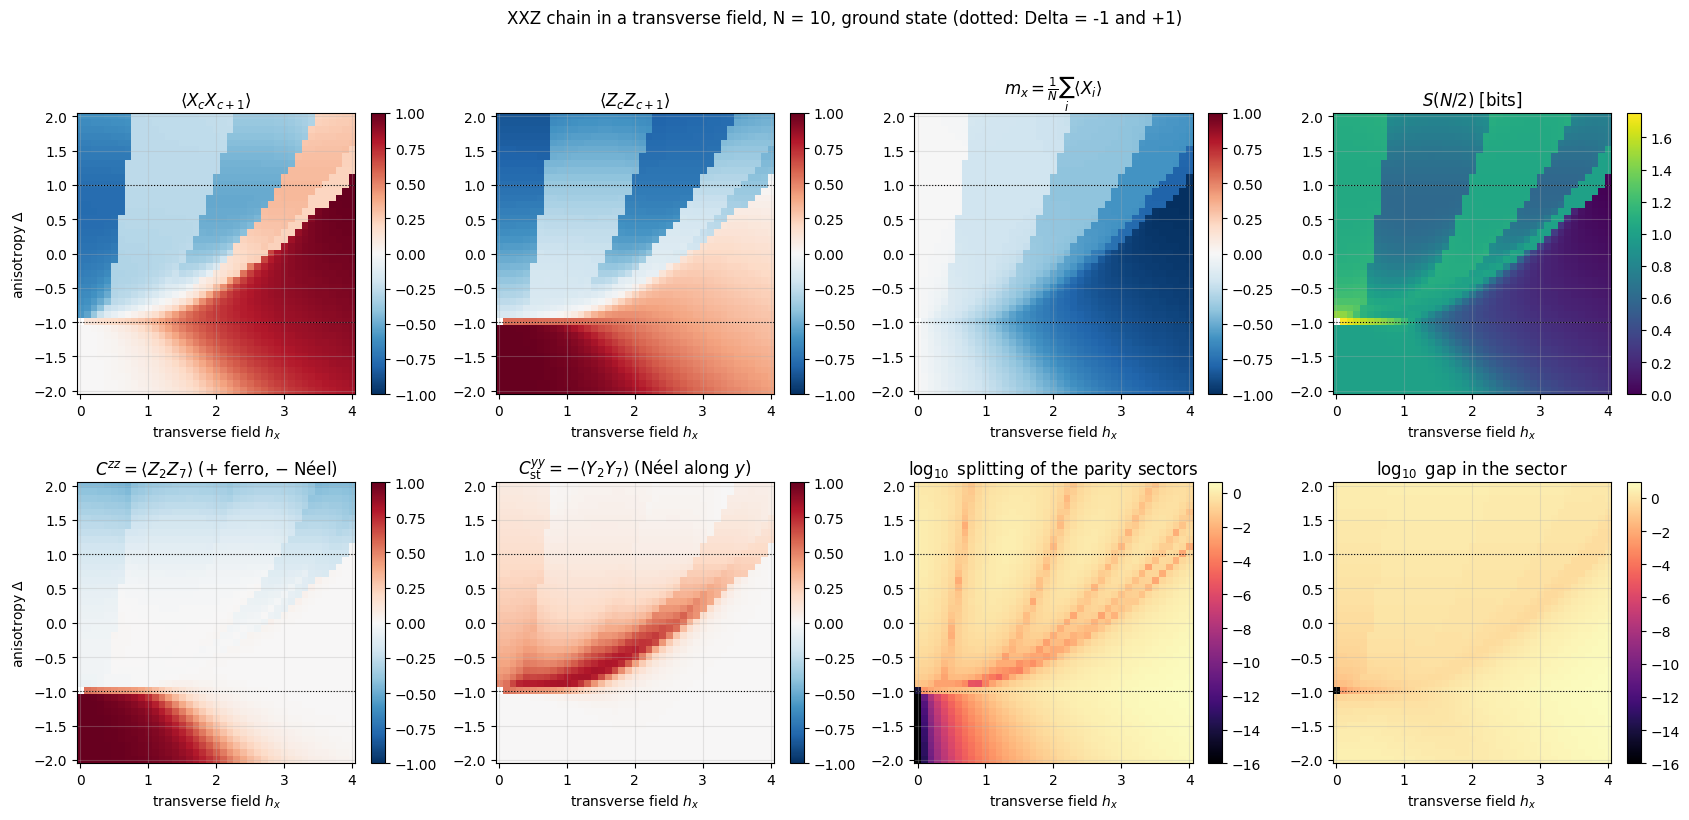

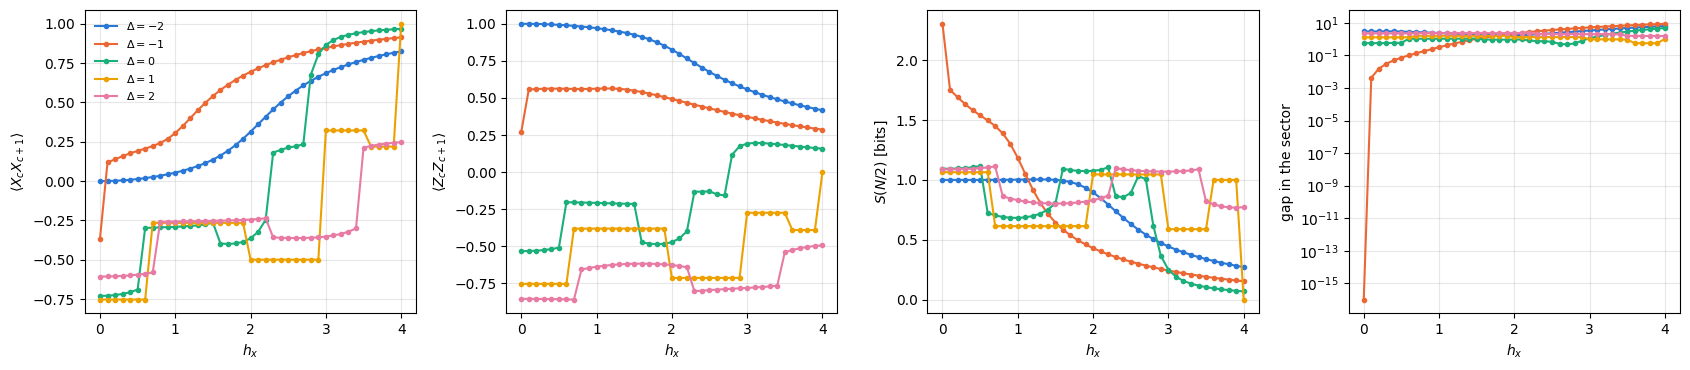

Delta = -2: | h_x=0: XX +0.000 ZZ +1.000 mx +0.000 S 1.000 Czz +1.000 Cyy_st -0.000 gap 2.996 split 0.0e+00 | h_x=1: XX +0.054 ZZ +0.971 mx -0.216 S 1.002 Czz +0.964 Cyy_st +0.000 gap 2.409 split 2.7e-04 | h_x=2: XX +0.314 ZZ +0.826 mx -0.488 S 0.896 Czz +0.657 Cyy_st +0.005 gap 1.762 split 1.3e-01 | h_x=3: XX +0.686 ZZ +0.558 mx -0.741 S 0.444 Czz +0.132 Cyy_st +0.005 gap 3.437 split 1.2e+00 | h_x=4: XX +0.825 ZZ +0.417 mx -0.849 S 0.271 Czz +0.028 Cyy_st +0.002 gap 6.484 split 2.8e+00
Delta = -1: | h_x=0: XX -0.365 ZZ +0.270 mx +0.000 S 2.305 Czz +0.270 Cyy_st +0.365 gap 0.000 split 5.3e-15 | h_x=1: XX +0.305 ZZ +0.563 mx -0.381 S 1.184 Czz +0.355 Cyy_st +0.355 gap 0.320 split 9.0e-02 | h_x=2: XX +0.695 ZZ +0.493 mx -0.722 S 0.430 Czz +0.039 Cyy_st +0.039 gap 2.213 split 1.0e+00 | h_x=3: XX +0.847 ZZ +0.373 mx -0.863 S 0.243 Czz +0.005 Cyy_st +0.005 gap 5.295 split 2.6e+00 | h_x=4: XX +0.914 ZZ +0.287 mx -0.924 S 0.153 Czz +0.001 Cyy_st +0.001 gap 8.859 split 4.3e+00
Delta = +0: | h_

In [43]:
# ==============================================================================
# FIGURE: phase diagram of four observables, and cuts at fixed Delta
# ==============================================================================
extent = [FIELDS_X[0] - 0.05, FIELDS_X[-1] + 0.05, DELTAS[0] - 0.05, DELTAS[-1] + 0.05]
panels = [("XX", r"$\langle X_cX_{c+1}\rangle$", "RdBu_r", (-1, 1)), ("ZZ", r"$\langle Z_cZ_{c+1}\rangle$", "RdBu_r", (-1, 1)),
          ("mx", r"$m_x=\frac{1}{N}\sum_i\langle X_i\rangle$", "RdBu_r", (-1, 1)), ("S", r"$S(N/2)$ [bits]", "viridis", (0, None)),
          ("Czz", r"$C^{zz}=\langle Z_2Z_7\rangle$ ($+$ ferro, $-$ Néel)", "RdBu_r", (-1, 1)),
          ("Cyy_st", r"$C^{yy}_{\rm st}=-\langle Y_2Y_7\rangle$ (Néel along $y$)", "RdBu_r", (-1, 1)),
          ("split", r"$\log_{10}$ splitting of the parity sectors", "magma", (None, None)), ("gap", r"$\log_{10}$ gap in the sector", "magma", (None, None))]
fig, axes = plt.subplots(2, 4, figsize=(17, 8.0))
axes = axes.ravel()
for ax, (key_, title, cmap, (vmin, vmax)) in zip(axes, panels):
    data = np.where(deg, np.nan, R[key_])                       # degenerate point: the solver returns an arbitrary multiplet member
    if key_ in ("gap", "split"):
        data = np.log10(np.maximum(R[key_], 1e-16))
    im = ax.imshow(data, origin="lower", aspect="auto", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
    for d_line in (-1.0, 1.0):
        ax.axhline(d_line, color="k", lw=0.8, ls=":")
    ax.set_xlabel(r"transverse field $h_x$"); ax.set_title(title); fig.colorbar(im, ax=ax, fraction=0.046)
axes[0].set_ylabel(r"anisotropy $\Delta$"); axes[4].set_ylabel(r"anisotropy $\Delta$")
fig.suptitle(f"XXZ chain in a transverse field, N = {N_XXZ}, ground state (dotted: Delta = -1 and +1)", y=1.02)
plt.tight_layout(); plt.show()

cut_deltas = [-2.0, -1.0, 0.0, 1.0, 2.0]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for k_d, d in enumerate(cut_deltas):
    i = int(np.argmin(np.abs(DELTAS - d)))
    for ax, key_ in zip(axes, ("XX", "ZZ", "S", "gap")):
        y = R[key_][i]
        if key_ == "gap":
            ax.semilogy(FIELDS_X, np.maximum(y, 1e-16), "o-", ms=3, color=PALETTE[k_d], label=rf"$\Delta={d:g}$")
        else:
            ax.plot(FIELDS_X, y, "o-", ms=3, color=PALETTE[k_d], label=rf"$\Delta={d:g}$")
for ax, lab in zip(axes, (r"$\langle X_cX_{c+1}\rangle$", r"$\langle Z_cZ_{c+1}\rangle$", r"$S(N/2)$ [bits]", "gap in the sector")):
    ax.set_xlabel(r"$h_x$"); ax.set_ylabel(lab); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

# --- numbers quoted in the text --------------------------------------------------------------------
for d in cut_deltas:
    i = int(np.argmin(np.abs(DELTAS - d)))
    line = f"Delta = {d:+.0f}:"
    for hv in (0.0, 1.0, 2.0, 3.0, 4.0):
        j = int(np.argmin(np.abs(FIELDS_X - hv)))
        line += (f" | h_x={hv:g}: XX {R['XX'][i, j]:+.3f} ZZ {R['ZZ'][i, j]:+.3f} mx {R['mx'][i, j]:+.3f} S {R['S'][i, j]:.3f}"
                 f" Czz {R['Czz'][i, j]:+.3f} Cyy_st {R['Cyy_st'][i, j]:+.3f} gap {R['gap'][i, j]:.3f} split {R['split'][i, j]:.1e}")
    print(line)
i_max, j_max = np.unravel_index(np.nanargmax(np.where(deg, np.nan, R["S"])), R["S"].shape)
print(f"largest S(N/2) = {R['S'][i_max, j_max]:.3f} bits at Delta = {DELTAS[i_max]:+.1f}, h_x = {FIELDS_X[j_max]:.1f}")
i_m1 = int(np.argmin(np.abs(DELTAS + 1.0)))                     # the row Delta = -1, without the degenerate point h_x = 0
err_m1 = float(np.max(np.abs(R["Czz"][i_m1, 1:] - R["Cyy_st"][i_m1, 1:])))
print(f"CHECKPOINT Delta = -1, h_x > 0: max |C^zz - C^yy_st| = {err_m1:.1e}   (exact equality, see the text)")
assert err_m1 < 1e3 * TOL
for d in (-2.0, 2.0):
    i = int(np.argmin(np.abs(DELTAS - d)))
    print(f"Delta = {d:+.0f}, h_x = 0: splitting between the parity sectors = {R['split'][i, 0]:.1e}")
for d in cut_deltas:
    i = int(np.argmin(np.abs(DELTAS - d)))
    low = np.nonzero(R["S"][i] < 0.1)[0]
    print(f"Delta = {d:+.0f}: S(N/2) < 0.1 bit from h_x = {FIELDS_X[low[0]]:.1f}" if len(low) else f"Delta = {d:+.0f}: S(N/2) never below 0.1 bit for h_x <= 4",
          f"| smallest gap in the sector along the cut: {R['gap'][i].min():.2e} at h_x = {FIELDS_X[int(np.argmin(R['gap'][i]))]:.1f}")

**Reading the maps** (numbers printed above; $N=10$).

* **Ferromagnet** ($\Delta<-1$, small $h_x$). $\langle Z_cZ_{c+1}\rangle\approx C^{zz}\approx1$ and $S(N/2)=1$ bit: the ground state in the
  parity sector is the cat $(|{\uparrow\cdots\uparrow}\rangle+|{\downarrow\cdots\downarrow}\rangle)/\sqrt2$. The splitting between the parity
  sectors is $0$ at $h_x=0$ and $2.7\times10^{-4}$ at $\Delta=-2$, $h_x=1$: the $\mathbb Z_2$ symmetry $P$ is spontaneously broken. As the field grows the
  splitting becomes of order one ($0.13$ at $h_x=2$, $1.2$ at $h_x=3$), $C^{zz}$ decays ($0.66$, then $0.13$) and the entropy falls: the field
  drives the chain from the $z$ ferromagnet to a paramagnet polarised along $-x$, the same physics as the transverse-field Ising chain.
* **Polarised paramagnet** (large $h_x$, lower right). $m_x\to-1$, $\langle X_cX_{c+1}\rangle\to1$, $S(N/2)\to0$: a product state. At $\Delta=1$ it is
  reached exactly at $h_x=4$, where $\langle X_cX_{c+1}\rangle=1$, $m_x=-1$ and $S=0$; there the fully polarised state is an exact eigenstate.
* **Steps.** For $\Delta>-1$ every observable changes with $h_x$ in sharp steps. They are **level crossings** of the finite chain. At $\Delta=1$ the
  total $M_x=\sum_iX_i$ is conserved ($SU(2)$), and $m_x=M_x/N$ jumps by $2/N=0.2$ at each crossing ($0,-0.2,-0.4,-0.6,\dots$). Away from $\Delta=1$,
  $M_x$ is not conserved, but consecutive ground states still belong to alternating parity sectors, and states of different symmetry sectors may
  cross exactly; the crossings are the thin lines of vanishing splitting in the splitting map. In an infinite chain the steps merge into
  smooth curves, so in a finite chain they must not be read as a cascade of transitions.
* **Field-induced order along $y$.** $C^{yy}_{\rm st}$ is enhanced in a band of intermediate fields below the polarised region: along $\Delta=0$ it is
  $0.29$ at $h_x=0$ (the power-law correlation of the critical XX chain), $0.36$ at $h_x=2$, and it collapses to $0.09$ at $h_x=3$ and to $0.003$
  at $h_x=4$. This is the antiferromagnetic order along $y$ predicted for the field-induced phase; one chain length can only suggest it, and
  establishing long-range order needs the correlations at several $N$ (Exercise 9).
* **The ferromagnetic Heisenberg point** $\Delta=-1$, $h_x=0$ is the only degenerate point of the grid (masked in the maps, where any member of the multiplet could be returned). Next to it the
  entropy reaches its largest value, $1.75$ bits at $h_x=0.1$: the field selects a strongly entangled state from the remnant of the $(N+1)$-fold
  degenerate multiplet. Along the whole line $\Delta=-1$ the two long-distance correlators are *equal*, $C^{zz}=C^{yy}_{\rm st}$ ($0.355$ at $h_x=1$,
  $0.039$ at $h_x=2$; the checkpoint above confirms it to rounding). The equality is exact: the rotation $U_{\rm sub}$ of Section 10.3 maps the chain at
  $\Delta=-1$ onto the $SU(2)$ ferromagnet in a *staggered* field along $x$, and it reverses $Y_7$ on the odd site, so $C^{yy}_{\rm st}$ becomes
  $\langle Y_2Y_7\rangle$ in the rotated frame. The rotated Hamiltonian is invariant under rotations about $x$, and the rotation by $\pi/2$ exchanges
  the $y$ and $z$ components of every spin, so $\langle Y_2Y_7\rangle=\langle Z_2Z_7\rangle$.
* **The Néel side.** At $\Delta=2$, $h_x=0$ the correlations are antiferromagnetic ($\langle Z_cZ_{c+1}\rangle=-0.85$, $C^{zz}=-0.43$), but the splitting of the
  parity sectors is $0.79$, far from exponentially small: close to the isotropic point the Néel gap is small and the correlation length long,
  and a chain of ten spins is too short to show the doublet of the Néel phase.

### 10.7 The gap and the entropy versus $N$: telling the phases apart

A single chain length cannot decide whether a gap is finite or closing; the gap has to be followed as a function of $N$. We take four representative
points: the critical XX chain $(\Delta,h_x)=(0,0)$, where Eq. (14) predicts $\Delta_N=4\sin\frac{\pi}{2(N+1)}$; the same chain in a field $(0,1)$,
where the field should open a gap; the ferromagnet $(-2,0)$; and $(2,0)$, on the Néel side. For each $N=6,8,10,12$ we build the sectors afresh
(at $N=12$ each has dimension 2048) and record the gap in the sector and $S(N/2)$.

N =  6 done


N =  8 done


N = 10 done


N = 12 done

critical XX chain: gap in the sector vs Eq. (14):
   N =  6: gap = 0.8900837358   4 sin(pi/(2(N+1))) = 0.8900837358   N * gap = 5.341
   N =  8: gap = 0.6945927107   4 sin(pi/(2(N+1))) = 0.6945927107   N * gap = 5.557
   N = 10: gap = 0.5692593531   4 sin(pi/(2(N+1))) = 0.5692593531   N * gap = 5.693
   N = 12: gap = 0.4821467210   4 sin(pi/(2(N+1))) = 0.4821467210   N * gap = 5.786
critical  (0, 0): gap = [0.8901 0.6946 0.5693 0.4821],  S(N/2) = [1.0392 0.822  1.0933 0.9464]
field     (0, 1): gap = [1.5272 1.2619 1.0698 0.9293],  S(N/2) = [0.5181 1.0382 0.6826 1.0722]
ferro    (-2, 0): gap = [2.9358 2.983  2.9957 2.9989],  S(N/2) = [1. 1. 1. 1.]
Néel side (2, 0): gap = [3.194  2.6263 2.2486 1.9799],  S(N/2) = [1.0339 0.7592 1.0879 0.9117]


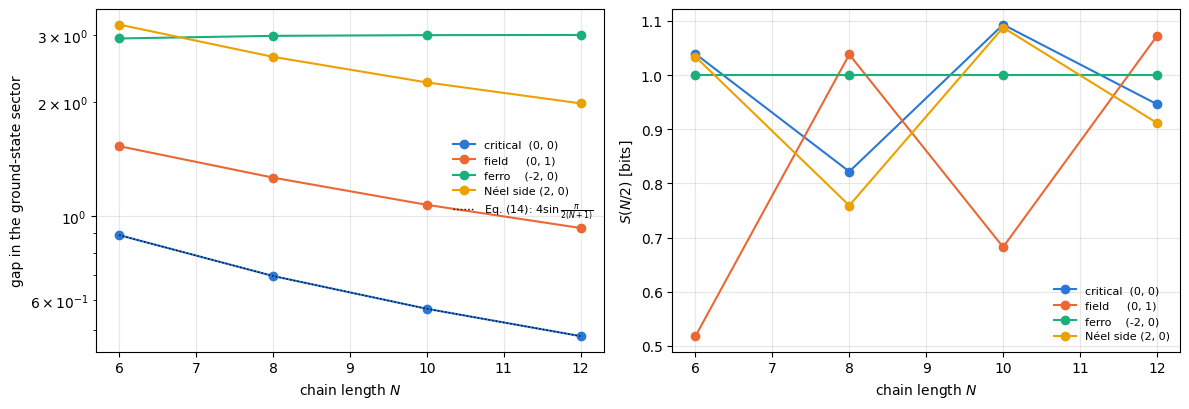

In [44]:
# ==============================================================================
# EXPERIMENT: gap in the sector and half-chain entropy versus N at four points
# ==============================================================================
N_SCALING = [6, 8, 10, 12]
POINTS = {"critical  (0, 0)": (0.0, 0.0), "field     (0, 1)": (0.0, 1.0), "ferro    (-2, 0)": (-2.0, 0.0), "Néel side (2, 0)": (2.0, 0.0)}

scal = {label: {"gap": [], "S": []} for label in POINTS}
for n in N_SCALING:
    _, bases_n, sparts_n = sector_setup(n)
    for label, (d, hv) in POINTS.items():
        w_p = jnp.linalg.eigvalsh(sparts_n[0][0] + d * sparts_n[0][1] + hv * sparts_n[0][2])
        w_m = jnp.linalg.eigvalsh(sparts_n[1][0] + d * sparts_n[1][1] + hv * sparts_n[1][2])
        w = w_m if float(w_m[0]) < float(w_p[0]) - DEGENERACY_TOL else w_p
        which = 1 if float(w_m[0]) < float(w_p[0]) - DEGENERACY_TOL else 0
        wv, vv = jnp.linalg.eigh(sparts_n[which][0] + d * sparts_n[which][1] + hv * sparts_n[which][2])
        psi_n = (bases_n[which] @ vv[:, 0]).astype(CDTYPE).reshape((2,) * n)
        scal[label]["gap"].append(float(w[1] - w[0]))
        scal[label]["S"].append(float(entanglement_entropy(psi_n, tuple(range(n // 2)))))
    print(f"N = {n:2d} done")

exact_gap = [4 * np.sin(np.pi / (2 * (n + 1))) for n in N_SCALING]
print("\ncritical XX chain: gap in the sector vs Eq. (14):")
for n, g_num, g_ex in zip(N_SCALING, scal["critical  (0, 0)"]["gap"], exact_gap):
    print(f"   N = {n:2d}: gap = {g_num:.10f}   4 sin(pi/(2(N+1))) = {g_ex:.10f}   N * gap = {n * g_num:.3f}")
    assert abs(g_num - g_ex) < 1e3 * TOL
for label in POINTS:
    print(f"{label}: gap = {np.round(scal[label]['gap'], 4)},  S(N/2) = {np.round(scal[label]['S'], 4)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for k_l, label in enumerate(POINTS):
    axes[0].plot(N_SCALING, scal[label]["gap"], "o-", color=PALETTE[k_l], label=label)
    axes[1].plot(N_SCALING, scal[label]["S"], "o-", color=PALETTE[k_l], label=label)
axes[0].plot(N_SCALING, exact_gap, "k:", lw=1, label=r"Eq. (14): $4\sin\frac{\pi}{2(N+1)}$")
axes[0].set_xlabel("chain length $N$"); axes[0].set_ylabel("gap in the ground-state sector"); axes[0].set_yscale("log")
axes[1].set_xlabel("chain length $N$"); axes[1].set_ylabel(r"$S(N/2)$ [bits]")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**What the sizes tell, and what they cannot.**

* **Critical XX chain.** The gap agrees with Eq. (14) to all printed digits, and $N\Delta_N$ grows towards $2\pi$ ($5.34,5.56,5.69,5.79$): the gap
  closes as $1/N$. The entropy alternates with the parity of $N/2$ (an effect of the open ends), but within each parity it grows
  ($1.04\to1.09$ for $N=6,10$ and $0.82\to0.95$ for $N=8,12$), as the logarithm of a critical state does.
* **Ferromagnet.** The gap in the sector converges to $3.0$ and the entropy is exactly $1$ bit for every $N$: a gapped phase with a broken symmetry,
  whose cat state carries one bit. The value $3$ differs from the ring value $4(|\Delta|-1)=4$ of Eq. (9) because on an **open** chain the cheapest
  excitation is a magnon bound to an end. At $\Delta=-2$ a flipped end spin breaks one bond, which costs $-2\Delta=4$, a flipped bulk spin two bonds, $-4\Delta=8$, and the
  hopping amplitude is $2$. For amplitudes $a_n=x^n$ with $|x|<1$, decaying away from the end $n=0$, the bulk and boundary equations are

  $$ E\,a_n=8a_n+2(a_{n-1}+a_{n+1})\ (n\ge1),\qquad E\,a_0=4a_0+2a_1
     \quad\Longrightarrow\quad E=8+2\big(x+\tfrac1x\big)=4+2x\quad\Longrightarrow\quad x=-\tfrac12,\ \ E=3 . \tag{16}$$

  The cell below confirms it with the exact one-magnon spectrum of the open chain: two levels, one bound to each end and slightly mixed, approach
  $3$ from both sides.
* **The Néel side and the field.** At $(2,0)$ the gap still decreases at $N=12$ ($3.19\to1.98$), and at $(0,1)$ it decreases as well ($1.53\to0.93$).
  The theory predicts finite gaps at both points, but the correlation lengths there are comparable to the chains we can diagonalise, and
  $N\le12$ cannot decide between a finite limit and a slow closing. This is the practical limit of exact diagonalisation, and the reason for the
  methods of later chapters: iterative eigensolvers that reach $N\approx20$–$24$, finite-size scaling, and matrix product states for hundreds of spins.

In [45]:
# ==============================================================================
# CHECKPOINT: the end-bound magnon of the open ferromagnetic chain, Eq. (16)
# ==============================================================================
for n in (8, 12):
    H_open = np.asarray(jnp.real(dense_hamiltonian(heisenberg_terms(n, Jxx=1.0, Jyy=1.0, Jzz=-2.0), n)))
    one_flip_open = [2 ** (n - 1 - m) for m in range(n)]
    w_open = np.sort(np.linalg.eigvalsh(H_open[np.ix_(one_flip_open, one_flip_open)])) - (-2.0) * (n - 1)   # relative to E_ref
    print(f"open chain N={n:2d}, Delta=-2: two lowest one-magnon energies above the reference = {w_open[0]:.6f}, {w_open[1]:.6f}   (Eq. 16: 3)")
    assert abs(0.5 * (w_open[0] + w_open[1]) - 3.0) < 0.05

open chain N= 8, Delta=-2: two lowest one-magnon energies above the reference = 2.983038, 3.018273   (Eq. 16: 3)


open chain N=12, Delta=-2: two lowest one-magnon energies above the reference = 2.998905, 3.001103   (Eq. 16: 3)


## 11. Measured cost

The cost model of this notebook is simple. With $D=2^N$:

| operation | time | memory | note |
|---|---|---|---|
| `rdm(psi, A)` | $O(D\,2^{\vert A\vert})$ | $O(D+4^{\vert A\vert})$ | a matrix product $MM^\dagger$ in disguise |
| `expect_local` | same + $O(4^{\vert A\vert})$ | | one RDM serves all operators on $A$ |
| `expect_pauli_string` (weight $k$) | $O(k\,D)$ | $O(D)$ | any weight |
| `entanglement_entropy(psi, A)` | $O(D\,2^{\min(\vert A\vert,\vert B\vert)})$ | $O(D)$ | SVD; worst case (half cut) $O(D^{3/2})$ |
| dense textbook route | $O(D^2)$–$O(D^3)$ | $O(D^2)$ | impossible beyond $N\approx14$ |

We now *measure* it. Rules for timing JAX code (notebook 01): JAX dispatches work asynchronously, so we wait for the result with `jax.block_until_ready`; the first call of a jitted function includes tracing and
XLA compilation, so we time it separately. The subsystem labels are **static** arguments — they determine the einsum string, hence the compiled program — so each distinct `keep` compiles its own program;
we fix them with `functools.partial` before `jax.jit`.

  N  state [MB] |                      rdm, 1 spin |   <Z_0 Z_{N-1}> via expect_local |   <X..X> Pauli string (weight N) |         half-chain entropy (SVD)      (run time; first call incl. compile in brackets)


  8        0.00 |             0.12 ms (  0.22 s) |             0.15 ms (  0.35 s) |             1.98 ms (  0.59 s) |             0.09 ms (  0.35 s)


 12        0.06 |             0.15 ms (  0.26 s) |             1.65 ms (  0.34 s) |             0.70 ms (  0.82 s) |             0.67 ms (  0.34 s)


 16        1.00 |             0.86 ms (  0.12 s) |             1.24 ms (  0.29 s) |            13.11 ms (  0.72 s) |            28.69 ms (  0.30 s)


 20       16.00 |            11.75 ms (  0.11 s) |            41.64 ms (  0.38 s) |           312.74 ms (  1.26 s) |          2911.21 ms (  3.69 s)


 22       64.00 |            53.56 ms (  0.16 s) |           114.41 ms (  0.46 s) |           766.45 ms (  2.13 s) |                        (skipped)


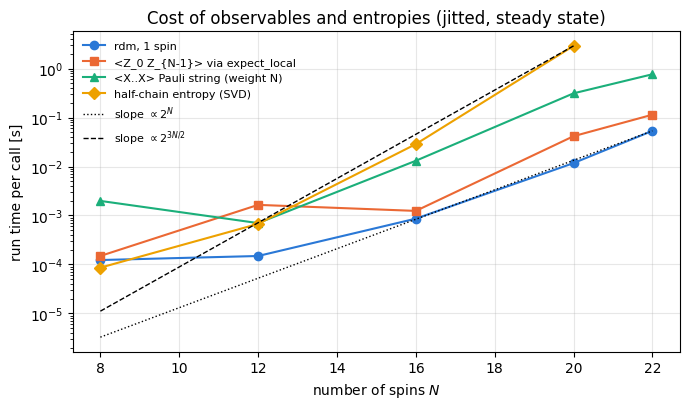

In [46]:
# ==============================================================================
# BENCHMARK: single-spin RDM, 2-spin correlator and half-chain entropy versus N
# ==============================================================================
def time_jitted(fn, arg, repeats=2):
    """Return (time of the first call incl. compilation, best steady-state time of `repeats` further calls), in seconds."""
    t0 = time.perf_counter(); jax.block_until_ready(fn(arg)); t_first = time.perf_counter() - t0
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter(); jax.block_until_ready(fn(arg)); best = min(best, time.perf_counter() - t0)
    return t_first, best


BENCH_N = [8, 12, 16, 20, 22]
results = {"rdm, 1 spin": [], "<Z_0 Z_{N-1}> via expect_local": [], "<X..X> Pauli string (weight N)": [], "half-chain entropy (SVD)": []}
print(f"{'N':>3s} {'state [MB]':>11s} | " + " | ".join(f"{k:>32s}" for k in results) + "      (run time; first call incl. compile in brackets)")
for n in BENCH_N:
    psi = haar_state(jax.random.PRNGKey(n), n)
    fns = {"rdm, 1 spin": jax.jit(partial(rdm, keep=(0,))),
           "<Z_0 Z_{N-1}> via expect_local": jax.jit(partial(expect_local, O=ZZ, qubits=(0, n - 1))),
           "<X..X> Pauli string (weight N)": jax.jit(partial(expect_pauli_string, ops="X" * n)),
           "half-chain entropy (SVD)": jax.jit(partial(entanglement_entropy, subsystem=tuple(range(n // 2))))}
    row = []
    for name, fn in fns.items():
        if name.startswith("half-chain") and n > 20:            # SVD of a 2048 x 2048 matrix: skip to stay in budget
            results[name].append(np.nan); row.append(f"{'(skipped)':>32s}"); continue
        t_first, t_run = time_jitted(fn, psi)
        results[name].append(t_run); row.append(f"{t_run * 1e3:16.2f} ms ({t_first:6.2f} s)")
    print(f"{n:3d} {psi.size * psi.dtype.itemsize / 2 ** 20:11.2f} | " + " | ".join(row))

fig, ax = plt.subplots(figsize=(7, 4.2))
for (name, ts_), c, m in zip(results.items(), PALETTE, MARKERS):
    ax.semilogy(BENCH_N, ts_, ls="-", color=c, marker=m, label=name)
ref = np.array(BENCH_N, dtype=float)
ax.semilogy(ref, results["rdm, 1 spin"][-1] * 2.0 ** (ref - ref[-1]), "k:", lw=1, label=r"slope $\propto 2^N$")
ax.semilogy(ref[:-1], results["half-chain entropy (SVD)"][-2] * 2.0 ** (1.5 * (ref[:-1] - ref[-2])), "k--", lw=1, label=r"slope $\propto 2^{3N/2}$")
ax.set_xlabel("number of spins $N$"); ax.set_ylabel("run time per call [s]"); ax.set_title("Cost of observables and entropies (jitted, steady state)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**Interpreting the benchmark.** (Absolute numbers depend on your machine and on what else it is doing; look at the trends.)

* For small $N$ all curves are flat: the run time is dominated by a constant dispatch overhead. From $N\approx16$ on, the RDM and the correlator grow roughly like the dotted $2^N$ line (single points can be off by a factor of a few when other jobs compete for the processor) —
  *linear in the size of the state*, which is the best one can hope for since every amplitude must be touched once.
* The weight-$N$ Pauli string costs $N$ passes over the state and lies one to two orders of magnitude above the single-spin RDM at large $N$.
* The half-chain entropy is the expensive one: SVD of a $2^{N/2}\times2^{N/2}$ matrix scales as $2^{3N/2}$ (dashed line). For *small* subsystems it is cheap again — cost $O(2^N2^{|A|})$.
* The first call (brackets) adds tracing and compilation, between a few hundredths of a second and about a second per distinct function, paid once; in a time-evolution loop the same compiled observable is called thousands of times.
* At $N=22$ the state occupies 64 MB. The textbook route through the $2^N\times2^N$ projector would need $4^{22}\times16$ bytes $\approx 280$ TB.

## 12. Key takeaways

* A many-body state is understood through **few-body reduced density matrices** and **entanglement across cuts**, rather than through its $2^N$ amplitudes.
* $\rho_A[a,a']=\sum_b\psi[a,b]\psi^*[a',b]$ is **one einsum**: shared letters for the traced spins, fresh letters for the kept ones. Cost $O(2^N2^{|A|})$; the $4^N$ projector is never formed.
  For a density tensor, the partial trace is a repeated letter inside a single operand.
* $\langle O_A\rangle=\mathrm{Tr}(\rho_AO_A)$. Use the RDM for few spins and many operators, apply-then-overlap for Pauli strings of any weight, one-einsum tables for all pairs of a diagonal observable.
* Entangled states look *mixed* locally. GHZ, Dicke and cluster states all have vanishing Bloch vectors; they differ in their two-body (GHZ, Dicke), three-body (cluster in the bulk) or $N$-body (GHZ) correlations.
* The **Schmidt decomposition is the SVD of the reshaped state tensor**; $p_k=\lambda_k^2$ is the spectrum of $\rho_A$ and of $\rho_B$. Entropies follow from the $p_k$; the SVD costs the same as diagonalising $\rho_A$ but resolves Schmidt values eight orders of magnitude smaller.
* GHZ: 1 bit for every bipartition. W: $h(\ell/N)\le1$ bit. Dicke: $\sim\tfrac12\log_2N$. Cluster: grows with the number of bonds crossing the boundary of $A$. **Random states: volume law**, Page value $\approx\ell-2^{2\ell-N}/(2\ln2)$, with negligible fluctuations.
* **Ground states of gapped local Hamiltonians obey an area law** with a rapidly decaying Schmidt spectrum — the reason matrix-product-state methods work. Critical points add a logarithm whose prefactor measures the central charge.
* The XXZ chain without field is solved by the **Bethe ansatz**: magnons with $\varepsilon(k)=4(\cos k-\Delta)$ that scatter pairwise with the phase of Eq. (10).
  The transverse field breaks the $U(1)$ symmetry and leaves only the spin flip $P$.
* **A first phase diagram** needs only these tools: build $H$ once as a linear combination of fixed matrices, diagonalise *within a symmetry sector* (here the spin flip $P=\prod_iX_i$) so that near-degenerate doublets cannot mix, and scan correlators, magnetisation and $S(N/2)$ over the parameters.
* Habits: validate against an independent dense reference on small $N$; make subsystem labels static and `jit`; `vmap` over keys or parameters instead of Python loops; clip before `log`; time with `block_until_ready`.

## 13. Exercises

1. ★ **By-hand strings.** For $N=4$ write the einsum strings for `keep=(1,)`, `keep=(3,0)` and for the density-tensor partial trace keeping spins `(1,2)`. Check each against `rdm`/`rdm_dm`
   with `assert max_abs(...) < TOL` on a Haar-random state.
2. ★ **Bloch vector and purity.** Verify numerically for every state of the zoo and every spin that $\mathrm{Tr}\rho_q^2=(1+|\vec r|^2)/2$ and that the single-spin entropy is $h\big((1+|\vec r|)/2\big)$.
3. ★★ **Mutual information.** Implement $I(A{:}B)=S_A+S_B-S_{AB}$ for two *single spins* $A=\{i\},B=\{j\}$ of a pure $N$-spin state (all three entropies come from `entanglement_entropy`, since the global state is pure).
   Plot $I(0{:}j)$ versus $j$ for GHZ, W, cluster and for the critical Ising ground state. Which state has $I=1$ bit at all distances?
   For the open cluster chain you should find $I(0{:}1)=1$ bit but $I(0{:}j)=0$ for every $j\ge2$: explain both using the stabilisers of
   Section 4.4 (which stabiliser is supported entirely on $\{0,1\}$?), and say what changes if the chain is closed into a ring.
4. ★★ **Extend the code: all correlators in any basis.** Generalise `xx_matrix_fast` to `yy_matrix_fast` (which single-spin rotation maps the $Y$ eigenbasis to the computational basis?) and verify against
   `correlation_matrix_loop(psi, Y)`. Then compute the connected correlation matrix of the critical ground state of Section 9 and plot $C^{ZZ}_{N/2,\,N/2+r}$ versus $r$ on a log–log scale. Compare with the gapped case on a lin–log scale.
5. ★★ **Page's deficit.** Reproduce the Page curve for $N=8$ and $N=12$ and plot the half-chain deficit $N/2-\langle S\rangle$ versus $N$. Also compute $\langle S_2\rangle$; show numerically that the mean purity is
   $\langle\mathrm{Tr}\rho_A^2\rangle=(d_A+d_B)/(d_Ad_B+1)$.
6. ★★ **The cat in the ferromagnet (physics).** Compute the Ising ground state for $h=0.3$ and $N=10$ with `lanczos_ground_state` using several different PRNG keys for the start vector. Record $\langle X^{\otimes N}\rangle$ (the parity), $\langle Z_0\rangle$ and $S(N/2)$.
   Explain the scatter of the results using the near-degenerate doublet. Then add a tiny symmetry-breaking field $-10^{-3}\sum_iZ_i$ and repeat.
7. ★★★ **Compression by Schmidt truncation (extend the code).** For the critical ground state at $N=14$, truncate Eq. (3) at the half cut to the $\chi$ largest Schmidt values, renormalise, and compute the fidelity with the exact state and the error of
   $\langle Z_6Z_7\rangle$ as functions of $\chi$. Show that the infidelity equals the discarded weight. Repeat with a random state. How many numbers does the truncated state need?
8. ★★★ **Entanglement growth (physics).** Using `apply_gate` and the Trotter gates of notebook 05, evolve $|{\uparrow\uparrow\dots\uparrow}\rangle$ under the critical Ising Hamiltonian ($N=12$) and plot $S(N/2)$ versus time. Identify the linear growth and the saturation
   value; compare the latter with the Page value. What does this imply for MPS simulations of quenches?
9. ★★ **The phase diagram at another size (physics).** Repeat the scan of Section 10 for $N=8$ and $N=12$ (at $N=12$ each sector has dimension 2048; use a coarser grid).
   Which features of the maps move with $N$ and which do not? Along the line $\Delta=0$, plot the gap in the sector against $h_x$ for the three sizes:
   where does it close, and what does that suggest about the thermodynamic limit? (The systematic tools, finite-size scaling of gaps and of the
   fidelity susceptibility, are the subject of a later chapter.)
   Finally, follow $C^{yy}_{\rm st}$ at the largest distance available for $N=8,10,12$ at $(\Delta,h_x)=(0,2)$: does it approach a nonzero value (long-range order)?
10. ★★ **Two magnons (physics).** For a ring of $N=8$ spins at $\Delta=0.5$, solve the Bethe equations (11) for $M=2$ numerically and compare the energies
   $E_{\rm ref}+\varepsilon(k_1)+\varepsilon(k_2)$ with the spectrum of $H$ in the sector of two flipped spins (28 states). Which solutions have complex
   momenta, and what do they describe? (Hint: write $k_{1,2}=K/2\pm iq$ and look at $|a(n_1,n_2)|$ as a function of $n_2-n_1$.)

## References

* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000) — reduced density matrices and Schmidt decomposition (Sec. 2.4–2.5), fidelity and trace distance (Ch. 9).
* R. Horodecki, P. Horodecki, M. Horodecki, K. Horodecki, *Quantum entanglement*, Rev. Mod. Phys. **81**, 865 (2009).
* D. M. Greenberger, M. A. Horne, A. Zeilinger, *Going beyond Bell's theorem*, in *Bell's Theorem, Quantum Theory and Conceptions of the Universe*, ed. M. Kafatos (Kluwer, 1989), pp. 69–72; N. D. Mermin, *Extreme quantum entanglement in a superposition of macroscopically distinct states*, Phys. Rev. Lett. **65**, 1838–1840 (1990).
* W. Dür, G. Vidal, J. I. Cirac, *Three qubits can be entangled in two inequivalent ways*, Phys. Rev. A **62**, 062314 (2000) — GHZ versus W.
* R. H. Dicke, *Coherence in spontaneous radiation processes*, Phys. Rev. **93**, 99 (1954).
* H. J. Briegel and R. Raussendorf, *Persistent entanglement in arrays of interacting particles*, Phys. Rev. Lett. **86**, 910 (2001) — cluster states.
* C. A. Fuchs and J. van de Graaf, *Cryptographic distinguishability measures for quantum-mechanical states*, IEEE Trans. Inf. Theory **45**, 1216 (1999).
* D. N. Page, *Average entropy of a subsystem*, Phys. Rev. Lett. **71**, 1291 (1993); D. N. Page, *Information in black hole radiation*, Phys. Rev. Lett. **71**, 3743 (1993); proof: S. K. Foong and S. Kanno, *Proof of Page's conjecture on the average entropy of a subsystem*, Phys. Rev. Lett. **72**, 1148–1151 (1994).
* M. B. Hastings, *An area law for one-dimensional quantum systems*, J. Stat. Mech. **2007**, P08024 (2007); J. Eisert, M. Cramer, M. B. Plenio, *Colloquium: Area laws for the entanglement entropy*, Rev. Mod. Phys. **82**, 277 (2010).
* P. Calabrese and J. Cardy, *Entanglement entropy and quantum field theory*, J. Stat. Mech. **2004**, P06002 (2004) — the $\tfrac c6\ln[(N/\pi)\sin(\pi\ell/N)]+\text{const}$ formula for an open chain (their Eq. 2; the form with $2N/\pi$ used in Section 9 differs only in the constant) and its $\tfrac c3$ counterpart for a ring.
* U. Schollwöck, *The density-matrix renormalization group in the age of matrix product states*, Ann. Phys. **326**, 96 (2011).
* G. H. Golub and C. F. Van Loan, *Matrix Computations*, 4th ed. (Johns Hopkins University Press, 2013) — SVD, its backward stability and the error bounds quoted in Section 6.3.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling, B. P. Flannery, *Numerical Recipes: The Art of Scientific Computing*, 3rd ed. (Cambridge University Press, 2007) — Ch. 2.6 (singular value decomposition) and Ch. 11 (eigensystems); the parallel volume *Numerical Recipes in Fortran 90*, 2nd ed. (Cambridge University Press, 1996).
* H. Bethe, *Zur Theorie der Metalle. I. Eigenwerte und Eigenfunktionen der linearen Atomkette*, Z. Phys. **71**, 205–226 (1931) — the Bethe ansatz.
* C. N. Yang and C. P. Yang, *One-dimensional chain of anisotropic spin-spin interactions. I. Proof of Bethe's hypothesis for ground state in a finite system*, Phys. Rev. **150**, 321–327 (1966); *II. Properties of the ground-state energy per lattice site for an infinite system*, Phys. Rev. **150**, 327–339 (1966) — the XXZ chain for all $\Delta$.
* M. Takahashi, *Thermodynamics of One-Dimensional Solvable Models* (Cambridge University Press, 1999) — Bethe-ansatz solution of the XXZ chain.
* D. V. Dmitriev, V. Ya. Krivnov and A. A. Ovchinnikov, *Gap generation in the XXZ model in a transverse magnetic field*, Phys. Rev. B **65**, 172409 (2002).
* P. Jordan and E. Wigner, *Über das Paulische Äquivalenzverbot*, Z. Phys. **47**, 631–651 (1928); E. Lieb, T. Schultz and D. Mattis, *Two soluble models of an antiferromagnetic chain*, Ann. Phys. **16**, 407–466 (1961) — the XX chain as free fermions.
* T. Giamarchi, *Quantum Physics in One Dimension* (Oxford University Press, 2003) — Luttinger liquids and the critical phase of the XXZ chain.
* S. Coleman, *There are no Goldstone bosons in two dimensions*, Commun. Math. Phys. **31**, 259–264 (1973) — no spontaneous breaking of a continuous symmetry in a quantum field theory in two space-time dimensions.
* G. Vidal, J. I. Latorre, E. Rico and A. Kitaev, *Entanglement in quantum critical phenomena*, Phys. Rev. Lett. **90**, 227902 (2003).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/